# 1 · Introduction au machine learning et au deep learning — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch01_introduction/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 1.1 à 1.4 | vérifier tes exercices papier ✏️ | ✏️ | ★ | |
| A | 1.9 | Penguins : échantillons, features et labels | 📦 | ★ | 10 |
|  | 1.10 | MNIST : une image, 784 nombres | 📦 | ★ | 10 |
|  | 1.11 | Holmes et Verne : le texte devient des nombres | 📦 | ★★ | 15 |
|  | 1.12 | Taches solaires : tracer, lisser, repérer le cycle | 📦 | ★★ | 20 |
|  | 1.13 | Lire les data cards des quatre fils rouges | 🛠️ | ★★ | 15 |
| B | 1.14 | Mémoriser n'est pas apprendre | 🔮 | ★★ | 15 |
|  | 1.15 | Un système expert pour les manchots | 🔨 | ★★ | 20 |
|  | 1.16 | La boucle d'entraînement à la main | 🔨 | ★★ | 30 |
|  | 1.17 | Learning rate : trop prudent, trop pressé | 🔬 | ★★ | 20 |
|  | 1.18 | Un arbre de décision apprend les règles à ta place | 📦 | ★★ | 20 |
|  | 1.19 | Un manchot d'une espèce jamais vue | 🔮 | ★★ | 15 |
|  | 1.20 | Le score trop beau pour être vrai | 🐛 | ★★ | 20 |
| C | 1.21 | Regrouper les manchots sans leurs étiquettes | 📦 | ★★ | 20 |
|  | 1.22 | L'agent cuisinier : apprendre par la récompense | 🔬 | ★★ | 30 |
|  | 1.23 | Un réseau de neurones en boîte noire sur MNIST | 📦 | ★★ | 25 |
|  | 1.24 | Fabriquer du faux Holmes et du faux Verne | 🔨 | ★★★ | 35 |
| D | 1.25 | Battre l'expert : 95 % avec tes propres règles | 🏆 | ★★★ | 40 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Décrire les quatre fils rouges du workbook avec le vocabulaire du ML : échantillons, features, labels.
- Voir la différence entre mémoriser et généraliser, et évaluer honnêtement sur un jeu de test.
- Écrire des règles à la main, puis une vraie boucle d'entraînement, et comparer avec un modèle qui apprend seul ses règles.
- Faire tourner en boîte noire un clustering, un agent qui apprend par la récompense, un réseau de neurones et un générateur de texte.

**Rappel express.** Un dataset est un tableau : une ligne par **échantillon**, une colonne par **feature**, plus le **label** à prédire. Entraîner : prédire, mesurer l'erreur (la **loss**), corriger les **paramètres** d'un pas réglé par le **learning rate**. On mesure la **généralisation** sur un **jeu de test** mis de côté, jamais utilisé pour apprendre. $\text{accuracy} = \frac{\text{prédictions correctes}}{\text{nombre d'échantillons}}$. En scikit-learn : `model.fit(X_train, y_train)`, puis `model.predict(X_new)` ou `model.score(X_test, y_test)`.

## Partie 0 · Vérifier tes exercices papier (✏️ de 1.1 à 1.4)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125` ou `[7, -2]`), pas l'expression Python, sinon tu ne vérifies rien. Arrondis comme l'énoncé le demande. Les réponses pas encore remplies affichent ⏳.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
import numpy as np

**Ex 1.1 — Accuracy et erreurs à l'échelle d'un centre de tri**

In [3]:
wb.record("1.1a", 9905 / 10000, decimals=4)
wb.record("1.1b", 100 * (1 - 9905 / 10000), decimals=2, mistakes={"c'est l'accuracy : on demande le taux d'ERREUR": 0.99, "c'est l'accuracy en pourcentage : on demande le taux d'ERREUR, en %": 99.05, "95, c'est le NOMBRE d'erreurs : exprime-le en pourcentage des 10 000 chiffres": 95})
wb.record("1.1c", round(1_200_000 * (1 - 9905 / 10000)), mistakes={"on demande les chiffres MAL lus : multiplie par le taux d'erreur, pas par l'accuracy": 1_188_600})
wb.record("1.1d", (9905 / 10000) ** 5, decimals=4, mistakes={"c'est l'approximation 1 − 5 × 0,0095 : calcule la probabilité EXACTE que les 5 chiffres soient tous justes (0B, indépendance)": 0.9525, "un code compte 5 chiffres, et chacun doit être lu juste": 0.9905})
wb.record("1.1e", round(240_000 * (1 - (9905 / 10000) ** 5)), mistakes={"tu as arrondi trop tôt : garde la probabilité de d) sans l'arrondir avant de multiplier": 11_280, "tu as arrondi d) à 4 décimales avant de multiplier : garde toutes les décimales de ta calculatrice": 11_184, "tu comptes les CHIFFRES faux, pas les CODES faux : un code avec deux chiffres faux ne compte qu'une fois": 11_400})

WB_ANSWER {"decimals": 4, "hash": "d55c1299ddc64149aab9399991a7bc6343ebfaf00a1a9e0d8a182b9327caec86", "hash_coarse": "4d892158b9441ead51b76958222f4b307b83e097c8b86aa0721d75758ce84b27", "id": "1.1a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 1.1a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "7d752a6206db15772fafb1fcec6ee215e2c4fa009930b814f19e96151fff8e7d", "hash_coarse": "d3bd852b876e0fabfcbb44fd3735153b98c0d9edbb68bbc56edbd5bf01fdcc7b", "id": "1.1b", "kind": "float", "magnitude": -1, "mistakes": {"3681480e0e53cea6e3b4cab3fbc0dd3cf002d5d362677f3fa79e7ae6c2cca18c": "c'est l'accuracy : on demande le taux d'ERREUR", "526da34c6c4caccb6c15ccde9f135a46e09f15e2986763c458da149532d2acae": "c'est l'accuracy en pourcentage : on demande le taux d'ERREUR, en %", "e84687c73d52137876978e4c5f54c71697489abbcb692a046f459f2fe32367a5": "95, c'est le NOMBRE d'erreurs : exprime-le en pourcentage des 10 000 chiffres"}, "sign": 1}
📝 Ex 1.1b : réponse enregistrée (flo

**Ex 1.2 — Concerts : la valeur manquante et celle de demain**

In [4]:
wb.record("1.2a", int((1290 + 1390) / 2))
wb.record("1.2b", int((1550 - 1200) / (12 - 5)), mistakes={"du 5 au 12 mai, il y a 7 jours d'écart (7 intervalles), pas 8": 44})
wb.record("1.2c", int(1200 + 50 * (8 - 5)), mistakes={"c'est l'interpolation de a) : on demande la valeur donnée par la DROITE de b)": 1340})
wb.record("1.2d", int(1550 + 50 * (13 - 12)), mistakes={"c'est la prévision faite avec les deux derniers jours (question e) : utilise la droite de b)": 1580})
wb.record("1.2e", int(1550 + (1550 - 1520)), mistakes={"c'est la prévision de la droite de b) : ici, prolonge seulement la tendance des deux derniers jours": 1600})
wb.record("1.2f", round(1600 * 25 * 0.10), mistakes={"le groupe touche 10 % des ventes, pas la totalité": 40_000, "10 % s'écrit 0,10 (ou 10/100), pas 10": 400_000})

WB_ANSWER {"hash": "dc718ce250fc896d4e0a33340f548204ea516fa54ea1703e8150dfa743b2a309", "id": "1.2a", "kind": "int", "magnitude": 3, "sign": 1}
📝 Ex 1.2a : réponse enregistrée (int).
WB_ANSWER {"hash": "19210fe1624e0f77c5612a9d47fac2261c716ec03b930816b12d918e5ec3a8fa", "id": "1.2b", "kind": "int", "magnitude": 1, "mistakes": {"dc4461d739c7e44848d7dd7f2f75689a0ddb6b02c134a370c8c07e1e4fa2efb3": "du 5 au 12 mai, il y a 7 jours d'écart (7 intervalles), pas 8"}, "sign": 1}
📝 Ex 1.2b : réponse enregistrée (int).
WB_ANSWER {"hash": "f9bed738c5766e7bd6ba7ecb17fea57fa20b1b6f1bcf085e83e0c23289a4ac38", "id": "1.2c", "kind": "int", "magnitude": 3, "mistakes": {"d665bcec375b07e9552c3790d90da1b0d4bbbb64793edaefcb96ba1e9e580aee": "c'est l'interpolation de a) : on demande la valeur donnée par la DROITE de b)"}, "sign": 1}
📝 Ex 1.2c : réponse enregistrée (int).
WB_ANSWER {"hash": "6029a8d08666300dcc4719fe1845d3ae78b2a5d13a78c1123f0f3e86ef515d62", "id": "1.2d", "kind": "int", "magnitude": 3, "mistakes": 

**Ex 1.3 — Compter les connexions d'un réseau en couches**

In [5]:
wb.record("1.3a", 4 * 3 + 3 * 2, mistakes={"compte les connexions de CHAQUE paire de couches voisines (4 → 3, puis 3 → 2) ; pour une paire, multiplie les tailles": 12, "on ne compte pas les neurones, mais les connexions entre deux couches voisines": 9})
wb.record("1.3b", 4 * 3 + 3 * 2 + 3 + 2, mistakes={"un biais par NEURONE ; les 4 entrées ne sont pas des neurones": 4 * 3 + 3 * 2 + 4 + 3 + 2, "n'oublie pas les biais : un par neurone": 18})
wb.record("1.3c", 784 * 128 + 128 + 128 * 10 + 10, mistakes={"n'oublie pas un biais par neurone (128 + 10)": 784 * 128 + 128 * 10})
wb.record("1.3d", 784 * 256 + 256 + 256 * 10 + 10, mistakes={"n'oublie pas un biais par neurone (256 + 10)": 784 * 256 + 256 * 10})
wb.record("1.3e", 784 * 128 + 128 + 128 * 128 + 128 + 128 * 10 + 10, mistakes={"n'oublie pas un biais par neurone (128 + 128 + 10)": 784 * 128 + 128 * 128 + 128 * 10})

WB_ANSWER {"hash": "63d23d92259eb785fdab36b5b69accd4c1dade19e3536cef75b5bc80ff9893c5", "id": "1.3a", "kind": "int", "magnitude": 1, "mistakes": {"418620094596d0e218d169026a767cd4c6adc71c888a852376fb03cf445994c6": "compte les connexions de CHAQUE paire de couches voisines (4 → 3, puis 3 → 2) ; pour une paire, multiplie les tailles", "66f6a47741077f4bece8381c6143d3f2807379a7e7b4e36a8cfcb5c9d6f7f702": "on ne compte pas les neurones, mais les connexions entre deux couches voisines"}, "sign": 1}
📝 Ex 1.3a : réponse enregistrée (int).
WB_ANSWER {"hash": "932b2f407b13a9505f83c1fb4d022c08ac0cde68dc3a94096dad1803d63e4eaf", "id": "1.3b", "kind": "int", "magnitude": 1, "mistakes": {"48d5a2104a8dff745842ac47fd82890af89ee4a772a53fc4ca039044a39074c3": "un biais par NEURONE ; les 4 entrées ne sont pas des neurones", "9b3dc5212d501deffae220e5d9511cd9c29694177f72002739de65ed84032955": "n'oublie pas les biais : un par neurone"}, "sign": 1}
📝 Ex 1.3b : réponse enregistrée (int).
WB_ANSWER {"hash": "cb3a5

**Ex 1.4 — Moins de nombres pour dire la même chose**

In [6]:
wb.record("1.4a", 2, mistakes={"une feature qui vaut toujours 0 ne distingue aucun jour d'un autre": 3})
wb.record("1.4b", 68 * 2.2046, decimals=1)
wb.record("1.4c", 1, mistakes={"connaître l'une des deux valeurs suffit pour calculer l'autre": 2})
wb.record("1.4d", int(np.hypot(240, 320)), mistakes={"la distance à vol d'oiseau se calcule avec Pythagore, pas en additionnant les coordonnées": 560, "c'est le CARRÉ de la distance : prends la racine": 160_000})
wb.record("1.4e", [round(750 * 0.6), round(750 * 0.8)])
wb.record("1.4f", round(250 * 0.6 + 300 * 0.8), mistakes={"c'est la distance de Q au départ à vol d'oiseau : on veut sa position LE LONG de la route (projection)": 391})
wb.record("1.4g", round(abs(-250 * 0.8 + 300 * 0.6)), mistakes={"c'est le CARRÉ de la distance : prends la racine": 400})

WB_ANSWER {"hash": "cbd0f98702a50bc7ec94f5346026ddbcfa96b78065c0ae06b867544e86e9b885", "id": "1.4a", "kind": "int", "magnitude": 0, "mistakes": {"bc54359c8d29de0b196543566aee139d0b3d8cc9c811c3c4229cc666464fa57d": "une feature qui vaut toujours 0 ne distingue aucun jour d'un autre"}, "sign": 1}
📝 Ex 1.4a : réponse enregistrée (int).
WB_ANSWER {"decimals": 1, "hash": "2a610ce96d63bc2f9db81dcb9b5382d5188e5888d229a8ccfca21c76a4d0ee67", "hash_coarse": "b359bafa307a6b4018c7cf90d025a4ea5f3e4d87e2ccd09ba787724dbc9dd496", "id": "1.4b", "kind": "float", "magnitude": 2, "sign": 1}
📝 Ex 1.4b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash": "e055bf725f92d7e5a643993a8b7631b60ff1e1d34175fcb290a2e4abd4f2a7d7", "id": "1.4c", "kind": "int", "magnitude": 0, "mistakes": {"16a22816044bf1b91e5fa44721b15b3d16268e6f005353122cc5c10427ad68b3": "connaître l'une des deux valeurs suffit pour calculer l'autre"}, "sign": 1}
📝 Ex 1.4c : réponse enregistrée (int).
WB_ANSWER {"hash": "5494d81fc7c1d0668c

## Partie A · Les quatre fils rouges du workbook

Fiche §1.2.2 et « Les quatre fils rouges ». Tu ouvres les quatre datasets qui reviendront tout au long du workbook et tu les regardes avec le vocabulaire du chapitre : échantillons, features, labels, et le type de problème que chacun illustre.

In [7]:
# Tools for the notebook exercises (parts A to D)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")

### Ex 1.9 — Penguins : échantillons, features et labels 📦 ★ ⏱️ 10 min
**Objectif :** décrire un dataset tabulaire avec le vocabulaire du machine learning.  
**Prérequis :** 0A (pandas) · fiche §1.2.2 · livre §1.2.2, §1.3.1 · **Fil rouge :** Penguins · **Parcours :** R, C

Le dataset Palmer Penguins (déjà vu en 0A) décrit des manchots de trois espèces. Avec le vocabulaire du livre (§1.2.2) : chaque **ligne** est un **échantillon**, chaque **colonne** une **feature**, et la colonne que l'on cherche à prédire est le **label**. Ici, le label est l'espèce (`species`).

a) `n_samples` : le nombre d'échantillons de `penguins_all`.
b) `n_features` : le nombre de features qui décrivent chaque manchot quand le label est `species` (toutes les **autres** colonnes).
c) `species_counts` : le nombre de manchots de chaque espèce, **du plus fréquent au moins fréquent**, sous forme d'une liste de 3 entiers (`value_counts()`, puis `.tolist()`).
d) `n_complete` : le nombre de manchots qui n'ont **aucune** valeur manquante (`dropna()`).
e) `first_vector` : les 4 mesures du premier manchot, dans l'ordre de `MEASURES`, sous forme d'une liste (`penguins_all.loc[0, MEASURES]`). Ce manchot est désormais un **vecteur** (0B).
f) `label_for_mass` : si l'on voulait prédire la **masse** d'un manchot à partir de ses autres colonnes, quel serait le nom de la colonne label ?

In [8]:
penguins_all = wb.datasets.load_penguins()     # all the penguins, missing values included
MEASURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins_all.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [9]:
n_samples = len(penguins_all)
n_features = penguins_all.shape[1] - 1            # every column except the label
species_counts = penguins_all["species"].value_counts().tolist()
n_complete = len(penguins_all.dropna())
first_vector = penguins_all.loc[0, MEASURES].astype(float).tolist()
label_for_mass = "body_mass_g"
print(n_samples, n_features, species_counts, n_complete, first_vector, label_for_mass)

344 7 [152, 124, 68] 333 [39.1, 18.7, 181.0, 3750.0] body_mass_g


In [10]:
wb.record("1.9a", n_samples)
wb.record("1.9b", n_features, mistakes={"le label n'est pas une feature : compte toutes les AUTRES colonnes": 8})
wb.record("1.9c", species_counts, mistakes={"compte tous les manchots de penguins_all, pas seulement les complets": [146, 119, 68]})
wb.record("1.9d", n_complete, mistakes={"dropna() retire une ligne dès qu'UNE valeur manque, sexe compris": 342})
wb.record("1.9e", first_vector, decimals=1)
wb.record("1.9f", label_for_mass, mistakes={"le label est ce que l'on veut PRÉDIRE : ici, la masse": "species"})

WB_ANSWER {"hash": "dcf916cd6a35a9c84347d5d3474cac24c0134b7bf619b3614ecfb611cc5adb06", "id": "1.9a", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 1.9a : réponse enregistrée (int).
WB_ANSWER {"hash": "fe4161ae2a90a72080f3bd9ac3243771f5297693cfde4130a23cf680005e9451", "id": "1.9b", "kind": "int", "magnitude": 0, "mistakes": {"33578ba4ad490cbd3132a558799a2985195a900f5d6be3705d643c7b20d5278d": "le label n'est pas une feature : compte toutes les AUTRES colonnes"}, "sign": 1}
📝 Ex 1.9b : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["d7e6627fc2835a7e4b28546fc8aabdbd94457c8e1bbf2f6652cbc79d1c3be959", "bb86721c7688338ba541be2f6719bbf40a02adfe8010c203001e412c0aa4dda0", "de57602dc057216b2f26fae6a689a194c43f20bfd688881cc582138f865044ae"], "hash": "cf691d35b9cc727d3a526d93d62252c9523763258761d38ad997903e55d0ce9b", "id": "1.9c", "integer": true, "kind": "array", "mistakes": {"523b1c5815fc7130ed13b9cee09647066c2c2872822c1f5b684642c80dce8882": "compte tous les manchots de 

💡 Le mot « feature » dépend de la question posée : pour prédire l'espèce, la masse est une feature ; pour prédire la masse, c'est l'espèce qui devient une feature. 9 des 11 manchots au sexe inconnu ont toutes leurs mesures, mais `dropna()` les retire quand même ; pour ne regarder que certaines colonnes, `dropna(subset=MEASURES)` (0A).

### Ex 1.10 — MNIST : une image, 784 nombres 📦 ★ ⏱️ 10 min
**Objectif :** voir qu'une image n'est, pour un ordinateur, qu'un tableau de nombres.  
**Prérequis :** 0A (NumPy, `wb.plot.show_images`) · fiche « Les quatre fils rouges » · livre §1.1.1, §1.7 · **Fil rouge :** MNIST · **Parcours :** R, C

MNIST contient 70 000 chiffres écrits à la main (60 000 pour l'entraînement, 10 000 pour le test), en niveaux de gris : chaque pixel est un entier, d'autant plus grand que l'encre est foncée. Le livre y revient souvent (§1.7), le workbook aussi.

a) `shape_mnist` : la forme de `X_mnist` (un tuple).
b) `n_pixels` : le nombre de pixels d'**une** image.
c) `pixel_range` : la liste `[plus petite valeur, plus grande valeur]` des pixels de tout `X_mnist`.
d) `first_label` : le label de la première image.
e) `n_ink` : le nombre de pixels **non nuls** de la première image (un masque booléen, 0A).
f) `most_common_digit` : le chiffre le plus fréquent parmi les labels `y_mnist` (`np.bincount`, puis `argmax`).

La vérification affiche ensuite 16 autres images avec leur label, et un morceau de la première image **en nombres**.

In [11]:
X_mnist, y_mnist = wb.datasets.load_mnist("train")   # 60 000 training images and their labels
print(type(X_mnist), X_mnist.dtype)

<class 'numpy.ndarray'> uint8


(60000, 28, 28) 784 [0, 255] 5 166 1 [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


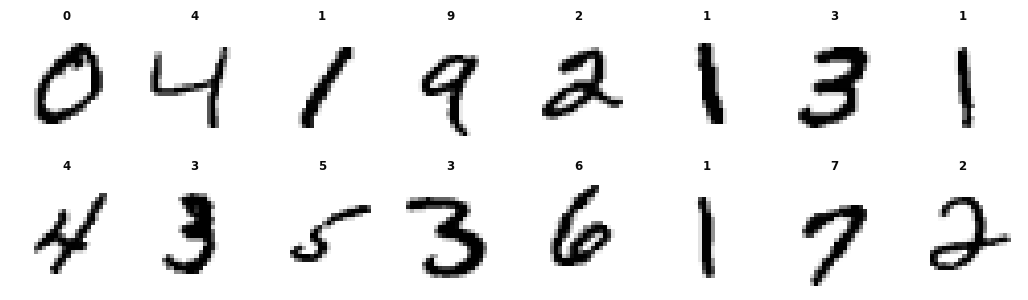

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
  247 127]
 [  0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242
  195  64]
 [  0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56
   39   0]
 [  0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0
    0   0]
 [  0   0   0   0  80 156 107 253 253 205  11   0  43 154   0   0   0   0
    0   0]
 [  0   0   0   0   0  14   1 154 253  90   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0 139 253 190   2   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0  11 190 253  70   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0  35 241 225 160 108   1   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0   0  81 240 253 253 119  25   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0   0   0  45 186 253 253 150  27

In [12]:
shape_mnist = X_mnist.shape
n_pixels = 28 * 28
pixel_range = [int(X_mnist.min()), int(X_mnist.max())]
first_label = int(y_mnist[0])
n_ink = int((X_mnist[0] > 0).sum())
most_common_digit = int(np.bincount(y_mnist).argmax())
print(shape_mnist, n_pixels, pixel_range, first_label, n_ink, most_common_digit, np.bincount(y_mnist))
wb.plot.show_images(X_mnist[1:17], y_mnist[1:17], ncols=8)
plt.show()
print(X_mnist[0][4:24, 4:24])

In [13]:
wb.record("1.10a", shape_mnist, mistakes={"une image est un tableau 28 × 28 : la forme compte trois nombres (images, lignes, colonnes)": [60000, 784]})
wb.record("1.10b", n_pixels)
wb.record("1.10c", pixel_range)
wb.record("1.10d", first_label)
wb.record("1.10e", n_ink, mistakes={"compte les pixels NON NULS (l'encre), pas les pixels de fond": 784 - n_ink})
wb.record("1.10f", most_common_digit)

WB_ANSWER {"decimals": 0, "element_hashes": ["e480f8742a656b20b30b72661d2a0342eae93add108f50b26265d509ab3b164e", "41368f407984df03eb4e3915be8dd728b0cbbf97591497ece785c5a48a453e1b", "6d1078481c59484c689a29c7317f387acdbdea79f97c776f6d9b13f3fa22ceb0"], "hash": "4662d607cae87096c26c3cb8c3222899547277cb4bb257b5a025e71c1a024d2b", "id": "1.10a", "integer": true, "kind": "array", "mistakes": {"a79c4fe242adb0cc1235181268038ec557516927544fe318d7bca5915481a4b7": "une image est un tableau 28 × 28 : la forme compte trois nombres (images, lignes, colonnes)"}, "shape": [3]}
📝 Ex 1.10a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "43c99d1fb6c51454711175f0a71b7de5ba2e0bb32ee6c81c6a8cc77487fca942", "id": "1.10b", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 1.10b : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["b441b481e3b5c56b86b93df78ad67d152b4385a89456dc3217240500a6684857", "629d238ac7702718547fbcd5b24ca63e3cae6a5dc4fe75e5e796263a109688d2"], "hash": "d6

💡 Pour un ordinateur, une image n'est qu'une grille de nombres. « Aplatie » (`reshape(784)`), elle devient un vecteur de 784 features : c'est ainsi que le réseau de 1.23 la verra. Les classes sont presque équilibrées : de 5 421 (chiffre 5) à 6 742 (chiffre 1) images.

### Ex 1.11 — Holmes et Verne : le texte devient des nombres 📦 ★★ ⏱️ 15 min
**Objectif :** transformer un texte en nombres (codes des caractères, fréquences des lettres) et comparer deux textes avec une distance.  
**Prérequis :** 0A (chaînes, `Counter`) · 0B (distance entre vecteurs) · fiche « Les quatre fils rouges » · livre §1.1.1 · **Fil rouge :** Holmes/Verne · **Parcours :** R, M, C

Deux romans du domaine public servent de fils rouges « texte » : *The Adventures of Sherlock Holmes* (anglais) et *Le Tour du monde en quatre-vingts jours* (français). Pour un ordinateur, un texte est une suite de caractères, et chaque caractère a un numéro (son code Unicode, `ord`).

a) `n_chars` : la liste `[nombre de caractères de holmes, nombre de caractères de verne]`.
b) `codes` : la liste des codes (`ord`) des 4 caractères de la chaîne `"Aa é"` (l'espace compte).
c) `n_distinct` : la liste `[nombre de caractères différents dans holmes, … dans verne]` (`set`). Pourquoi le français en a-t-il davantage ?
d) et e) `letter_freq(text)` : le vecteur des **26 fréquences** des lettres de `a` à `z`. On passe le texte en minuscules (`text.lower()`), on ne garde que les caractères entre `"a"` et `"z"` (les lettres accentuées ne comptent pas), puis la fréquence d'une lettre est son nombre d'apparitions divisé par le nombre total de lettres gardées. La vérification regarde d) `letter_freq(holmes)` et e) `letter_freq(verne)` (3 décimales).
f) `distances` : la liste `[d_halves, d_languages]` (4 décimales), où `d_halves` est la distance (norme de la différence, 0B) entre les vecteurs de fréquences des deux moitiés de `holmes` (`holmes[:len(holmes) // 2]` et `holmes[len(holmes) // 2:]`), et `d_languages` la distance entre les vecteurs de `holmes` et de `verne`. Qu'en conclus-tu ?

In [14]:
holmes = wb.datasets.load_holmes()     # a str: the whole book, in English
verne = wb.datasets.load_verne()       # a str: the whole book, in French
print(holmes[:300])
print("-" * 60)
print(verne[:300])

The Adventures of Sherlock Holmes

by Arthur Conan Doyle


Contents

   I.     A Scandal in Bohemia
   II.    The Red-Headed League
   III.   A Case of Identity
   IV.    The Boscombe Valley Mystery
   V.     The Five Orange Pips
   VI.    The Man with the Twisted Lip
   VII.   The Adventure of the 
------------------------------------------------------------
Jules Verne

LE TOUR DU MONDE EN QUATRE-VINGTS JOURS

(1873)




Table des matières


I DANS LEQUEL PHILEAS FOGG ET PASSEPARTOUT S'ACCEPTENT RÉCIPROQUEMENT
L'UN COMME MAÎTRE, L'AUTRE COMME DOMESTIQUE

II OÙ PASSEPARTOUT EST CONVAINCU QU'IL A ENFIN TROUVE SON IDEAL

III OÙ S'ENGAGE UNE CONVERSATION Q


[562203, 421336] [65, 97, 32, 233] [88, 103] [0.0042 0.0875]


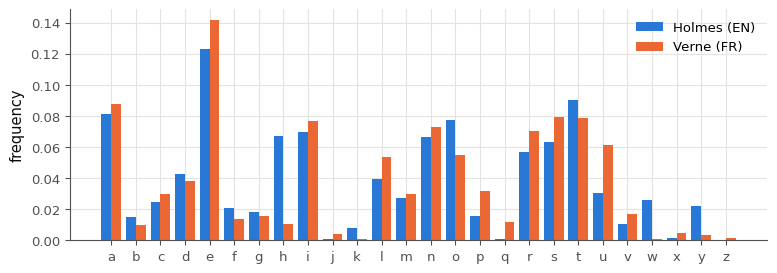

In [15]:
from collections import Counter

n_chars = [len(holmes), len(verne)]
codes = [ord(c) for c in "Aa é"]
n_distinct = [len(set(holmes)), len(set(verne))]


def letter_freq(text):
    """The 26 frequencies of the letters a to z among the letters a-z of text (in lower case), a NumPy array."""
    counts = Counter(c for c in text.lower() if "a" <= c <= "z")
    total = sum(counts.values())
    return np.array([counts[chr(k)] / total for k in range(ord("a"), ord("z") + 1)])


half = len(holmes) // 2
d_halves = np.linalg.norm(letter_freq(holmes[:half]) - letter_freq(holmes[half:]))
d_languages = np.linalg.norm(letter_freq(holmes) - letter_freq(verne))
distances = [d_halves, d_languages]
print(n_chars, codes, n_distinct, np.round(distances, 4))
letters = [chr(k) for k in range(ord("a"), ord("z") + 1)]
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(26) - 0.2, letter_freq(holmes), width=0.4, label="Holmes (EN)")
ax.bar(np.arange(26) + 0.2, letter_freq(verne), width=0.4, label="Verne (FR)")
ax.set_xticks(np.arange(26), letters)
ax.set_ylabel("frequency")
ax.legend()
plt.show()

In [16]:
wb.record("1.11a", n_chars)
wb.record("1.11b", codes)
wb.record("1.11c", n_distinct)
wb.record("1.11d", letter_freq(holmes), decimals=3)
wb.record("1.11e", letter_freq(verne), decimals=3)
wb.record("1.11f", distances, decimals=4, mistakes={"garde l'ordre demandé : d'abord les deux moitiés de Holmes, puis Holmes contre Verne": distances[::-1]})

WB_ANSWER {"decimals": 0, "element_hashes": ["0f4059f8b6c174ca415c30939e1d2aa9ebf423af4f87c0aad49849ec98bbd85f", "d051abd8830008cdf823e3b934a63c24c88278aa4ac89e79b5bf539b29a5886a"], "hash": "c48d378d8773f3342f21b6a08ce9d34194efd70b5d01fcb826bf70a15719c5c0", "id": "1.11a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 1.11a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["7ab1d7663f7fea0c5b60c96cee1e8277bdaf5c03f0af37c5baec1b3714059eb0", "824837dd048865a1c3b78adfc1e75850148179a40f8b600bc2c9039ad03b66c4", "cbe4d543f5bd721fa23556febf5a8aee743b8e35320120a42fbc96de50cef2ab", "ad5a8f748502548f0a6d0ff2d044afdef590f0ec1e534444ad9c1c28b4e244a2"], "hash": "e2151a69bbbc2b1b67f7584e163b77f251d3d243824b81c97fec346406fe0f03", "id": "1.11b", "integer": true, "kind": "array", "shape": [4]}
📝 Ex 1.11b : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["225cd05d23783996f8973a791d77d75314f0cf3cedc71782636004b68ca39a

💡 Le français utilise des lettres accentuées (é, è, à, ç…) : 103 caractères différents contre 88. Les deux moitiés de *Holmes* ont presque le même vecteur de fréquences, alors que Holmes et Verne sont environ vingt fois plus éloignés : les fréquences des lettres sont une signature de la langue (un `w` sur 40 lettres en anglais, presque aucun en français). Un classifieur de langue s'en sert (ch. 6 et 13).

### Ex 1.12 — Taches solaires : tracer, lisser, repérer le cycle 📦 ★★ ⏱️ 20 min
**Objectif :** explorer une série temporelle réelle, la débruiter par une moyenne mobile et mesurer son cycle.  
**Prérequis :** 0A (pandas) · 0B.4 (moyenne mobile) · fiche §1.3.2, §1.4.2 · livre §1.3.2, §1.4.2 · **Fil rouge :** taches solaires · **Parcours :** C

Le nombre mensuel de taches solaires a été reconstitué depuis 1749 et il est tenu à jour par le SILSO, à l'observatoire royal de Belgique. La série est très bruitée, mais cache un cycle célèbre. Deux idées du livre s'y rencontrent : le **débruitage** (§1.4.2) et la **régression** (§1.3.2 : prévoir la valeur du mois suivant, que tu feras au ch. 22).

a) `n_months` : le nombre de mois de la série `sun` (déjà limitée aux mois définitifs).
b) `record_year` : l'année du mois qui compte le plus de taches (`idxmax`, puis la colonne `year`).
c) `smooth` : la moyenne mobile sur 13 mois, **exactement** `sun["sunspots"].rolling(13).mean()` (la moyenne du mois et des 12 précédents, 0B.4) ; puis `n_missing`, le nombre de valeurs manquantes (`NaN`) de `smooth`. D'où viennent-elles ?
d) `peak_year` : l'année où la série **lissée** est la plus haute.
e) `peaks` : les positions des sommets de la série lissée, données par l'outil fourni `local_maxima(smooth.to_numpy(), 60)` (un mois est un sommet s'il est le plus haut à 60 mois près, avant comme après) ; puis `n_peaks`, leur nombre.
f) `mean_period` : la durée moyenne, en années (1 décimale), entre deux sommets successifs ; utilise la colonne `decimal_year` aux positions `peaks` et `np.diff`.

La vérification trace la série brute, la série lissée et les sommets.

In [17]:
sun = wb.datasets.load_sunspots(definitive_only=True)   # monthly sunspot numbers, final values only
print(sun[["date", "sunspots"]].head(3))


def local_maxima(values, half_window):
    """Positions t where values[t] is the largest value of values[t - half_window : t + half_window + 1]."""
    positions = []
    for t in range(half_window, len(values) - half_window):
        window = values[t - half_window: t + half_window + 1]
        if not np.isnan(window).any() and values[t] == window.max():
            positions.append(t)
    return positions

        date  sunspots
0 1749-01-01      96.7
1 1749-02-01     104.3
2 1749-03-01     116.7


3327 1778 12 1958 24 11.0


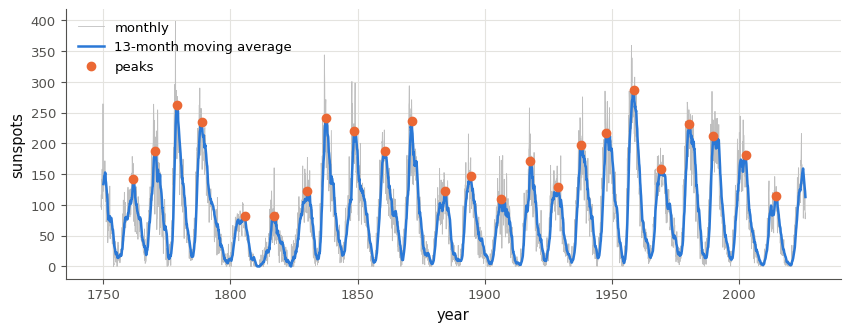

In [18]:
n_months = len(sun)
record_year = int(sun.loc[sun["sunspots"].idxmax(), "year"])
smooth = sun["sunspots"].rolling(13).mean()
n_missing = int(smooth.isna().sum())
peak_year = int(sun.loc[smooth.idxmax(), "year"])
peaks = local_maxima(smooth.to_numpy(), 60)
n_peaks = len(peaks)
mean_period = float(np.diff(sun["decimal_year"].to_numpy()[peaks]).mean())
print(n_months, record_year, n_missing, peak_year, n_peaks, round(mean_period, 2))
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(sun["decimal_year"], sun["sunspots"], color="0.75", lw=0.6, label="monthly")
ax.plot(sun["decimal_year"], smooth, lw=1.8, label="13-month moving average")
ax.plot(sun["decimal_year"].to_numpy()[peaks], smooth.to_numpy()[peaks], "o", label="peaks")
ax.set_xlabel("year")
ax.set_ylabel("sunspots")
ax.legend(loc="upper left")
plt.show()

In [19]:
wb.record("1.12a", n_months)
wb.record("1.12b", record_year, mistakes={"c'est le sommet de la série LISSÉE (question d) : ici, le mois brut record": peak_year})
wb.record("1.12c", n_missing, mistakes={"le mois t a besoin des 12 mois précédents : combien de mois au début n'en ont pas assez ?": 13})
wb.record("1.12d", peak_year, mistakes={"c'est le mois brut record (question b) : ici, le sommet de la série LISSÉE": record_year})
wb.record("1.12e", n_peaks)
years_12 = sun["decimal_year"].to_numpy()[peaks]
wb.record("1.12f", mean_period, decimals=1, mistakes={"entre 24 sommets, il y a 23 intervalles : c'est la moyenne des ÉCARTS (np.diff)": (years_12[-1] - years_12[0]) / n_peaks})

WB_ANSWER {"hash": "56c1adfc786cfa217edcb130aeedc60f855d2467a5276ca03bc55ed4c3ff7613", "id": "1.12a", "kind": "int", "magnitude": 3, "sign": 1}
📝 Ex 1.12a : réponse enregistrée (int).
WB_ANSWER {"hash": "fe5f4fd9be86cdf7c9e520d6e5f01c1ad6313d82bbc33efd216c4a47cd93ff85", "id": "1.12b", "kind": "int", "magnitude": 3, "mistakes": {"9ada187562e5015aaacbbadb149e06b0958c9e1a2d1c0fe6776c2e0ca7344b5f": "c'est le sommet de la série LISSÉE (question d) : ici, le mois brut record"}, "sign": 1}
📝 Ex 1.12b : réponse enregistrée (int).
WB_ANSWER {"hash": "2a929ecc8c3413d9c928eab48852404dfed48f7b9ae996f9313f45b45ca52d22", "id": "1.12c", "kind": "int", "magnitude": 1, "mistakes": {"f79d58eeff20b04fb911466afa0321bc416e80457adfb5fbc79823ee2ce4902f": "le mois t a besoin des 12 mois précédents : combien de mois au début n'en ont pas assez ?"}, "sign": 1}
📝 Ex 1.12c : réponse enregistrée (int).
WB_ANSWER {"hash": "f7c60036bbffdc9b6ef8688930be64fad80cf0e3c3e286c96744acba875529bd", "id": "1.12d", "kind": "in

💡 Le mois record (1778) n'est pas l'année du plus haut sommet lissé (1958) : un mois isolé peut être exceptionnel sans que le cycle le soit. Les 12 premiers mois n'ont pas assez d'historique pour une moyenne sur 13 mois. Le cycle solaire dure en moyenne environ 11 ans, mais chaque cycle varie de 9 à 14 ans environ, et son amplitude aussi : c'est ce qui rend la prévision difficile (ch. 22).

### Ex 1.13 — Lire les data cards des quatre fils rouges 🛠️ ★★ ⏱️ 15 min
**Objectif :** lire la fiche d'un dataset (provenance, licence, biais, limites) avant de s'en servir.  
**Prérequis :** Ex 1.9 à 1.12 · `data/cards/` · livre §1.8 · **Parcours :** C

Un professionnel ne se sert jamais d'un dataset sans lire sa **data card** (*fiche de données*) : d'où viennent les données, sous quelle licence, quels biais et quelles limites. Le workbook en a une par dataset, dans `data/cards/`. La cellule suivante affiche le catalogue et les fiches des quatre fils rouges.

Réponds dans la cellule **📝 Mes réponses** :
1. Pour chacun des cinq datasets (Penguins, MNIST, Holmes, Verne, taches solaires) : sa **licence**, et peux-tu t'en servir dans un **produit vendu** ?
2. Quelle limite de Penguins pourrait pousser un modèle à « tricher » en regardant une autre colonne que la morphologie ?
3. Pourquoi la fiche de MNIST dit-elle qu'un modèle médiocre peut y paraître bon ?
4. En quoi Holmes et Verne diffèrent-ils des textes sur lesquels on entraîne un LLM ?
5. Quelles précautions prendre pour les taches solaires avant d'enregistrer des résultats (colonne `definitive`) ?

In [20]:
print(wb.datasets.list_datasets()[["dataset", "type", "versionné", "fiche"]].to_string(index=False))
for name in ["penguins", "mnist", "holmes", "verne", "sunspots"]:
    print("=" * 80)
    wb.datasets.dataset_card(name)

           dataset                                            type        versionné                            fiche
          penguins                       tabulaire, classification              oui           data/cards/penguins.md
      penguins_raw                       tabulaire brut, nettoyage              oui           data/cards/penguins.md
california_housing                           tabulaire, régression              oui data/cards/california_housing.md
             mnist                       images 28×28, 10 chiffres              oui              data/cards/mnist.md
     fashion_mnist                      images 28×28, 10 vêtements non (téléchargé)      data/cards/fashion_mnist.md
           cifar10                images couleur 32×32, 10 classes non (téléchargé)            data/cards/cifar10.md
            holmes                                   texte anglais              oui             data/cards/holmes.md
             verne                                  texte frança

**Réponses (1.13)** :

1. Penguins : CC0 (domaine public), oui. MNIST : CC BY-SA 3.0, oui en citant les auteurs et en partageant dans les mêmes conditions tout dataset dérivé. Holmes et Verne : domaine public (Project Gutenberg), oui (la licence Gutenberg ne porte que sur les fichiers qui gardent son nom et son en-tête). Taches solaires : **CC BY-NC 4.0**, attribution obligatoire et **pas d'usage commercial**.
2. Les espèces sont liées aux îles (les Gentoo ne viennent que de Biscoe) : un modèle qui voit `island` peut apprendre l'île au lieu de la morphologie, et se tromper dès qu'on change d'île.
3. MNIST est « résolu » : les meilleurs modèles dépassent 99,7 % d'accuracy, et même un modèle simple dépasse 90 %. Un bon score sur MNIST prouve donc peu de chose ; Fashion-MNIST est plus exigeant.
4. Un seul auteur, un seul genre, une langue du XIXᵉ siècle, quelques centaines de milliers de caractères, contre des milliers de milliards de tokens de sources variées pour un LLM ; et les représentations sociales de l'époque.
5. Les derniers mois sont provisoires et peuvent être révisés : on les exclut (`definitive_only=True`) et on note la date de téléchargement ; les mesures du XVIIIᵉ siècle sont beaucoup plus bruitées.

💡 Au ch. 29, tu écriras la data card du dataset de ton projet final sur ce modèle : provenance, licence, taille, variables, biais et limites.

## Partie B · Apprendre à partir d'exemples étiquetés

Fiche §1.1.2 et §1.2. Les 333 manchots complets sont tirés au sort une fois pour toutes : 233 pour apprendre (le **jeu d'entraînement**) et 100 mis de côté (le **jeu de test**), qui ne servent qu'à mesurer si ce qui a été appris se **généralise**. Tu compares un modèle qui apprend par cœur, des règles écrites à la main, une vraie boucle d'entraînement et un modèle qui apprend ses règles tout seul.

In [21]:
# Penguins, split once and for all: a training set and a test set set aside
penguins = wb.datasets.load_penguins(dropna=True)     # the 333 complete penguins
MEASURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
rng_split = np.random.default_rng(42)                  # the random draw of the penguins set aside
order = rng_split.permutation(len(penguins))
test = penguins.iloc[order[:100]].reset_index(drop=True)    # 100 penguins set aside: the test set
train = penguins.iloc[order[100:]].reset_index(drop=True)   # 233 penguins to learn from: the training set
X_train, y_train = train[MEASURES], train["species"]
X_test, y_test = test[MEASURES], test["species"]


def accuracy(y_true, y_pred):
    """Proportion of correct predictions."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def predict_with(rule, X):
    """Apply rule(bill_length, bill_depth, flipper_length, body_mass) to every row of X."""
    return np.array([rule(*row) for row in X[MEASURES].to_numpy()])


print(f"training set: {len(train)} penguins · test set: {len(test)} penguins")

training set: 233 penguins · test set: 100 penguins


### Ex 1.14 — Mémoriser n'est pas apprendre 🔮 ★★ ⏱️ 15 min
**Objectif :** voir qu'un score parfait sur les exemples appris ne dit rien de la généralisation.  
**Prérequis :** Ex 1.9 · fiche §1.2.1, §1.2.3 · livre §1.2.1 à §1.2.3 · **Fil rouge :** Penguins · **Parcours :** R, C

Le `Memorizer` ci-dessous apprend « par cœur », comme l'école absurde du livre (§1.2.1) : pendant l'entraînement (`fit`), il range chaque manchot dans une table (ses 4 mesures → son espèce). Pour prédire (`predict`), il cherche les mesures du manchot dans sa table ; s'il ne les trouve pas, il répond l'espèce la plus fréquente de l'entraînement. Il a la même interface que les modèles de scikit-learn : `fit`, puis `predict` (encadré 🧮 de la fiche).

**Sans rien exécuter**, classe l'accuracy qu'il obtiendra dans une catégorie : `"parfaite"` (100 %), `"bonne"` (de 80 % à 100 % exclu), `"moyenne"` (de 50 % à 80 % exclu) ou `"mauvaise"` (moins de 50 %).

a) sur le **jeu d'entraînement** (les manchots qu'il a appris) ;
b) sur le **jeu de test** (100 manchots qu'il n'a jamais vus).

Écris ton hypothèse (cellule 📝), puis tes deux prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience**.

In [22]:
class Memorizer:
    """Learns by heart: a table (4 measures -> species). Unknown penguin: the most frequent species."""

    def fit(self, X, y):
        self.table_ = {tuple(row): label for row, label in zip(X.to_numpy(), y)}
        self.default_ = y.value_counts().idxmax()
        return self

    def predict(self, X):
        return np.array([self.table_.get(tuple(row), self.default_) for row in X.to_numpy()])

In [23]:
prediction_1_14a = "parfaite"
prediction_1_14b = "mauvaise"

In [24]:
wb.record("1.14a", prediction_1_14a, mistakes={"chaque manchot d'entraînement est DANS la table : le mémoriseur ne peut pas se tromper sur eux": "bonne"})
wb.record("1.14b", prediction_1_14b, mistakes={"un manchot du test a-t-il exactement les mêmes 4 mesures qu'un manchot appris ? Que répond alors le mémoriseur ?": "bonne",
                                                "retrouver un manchot appris est facile ; mais les manchots du test sont nouveaux": "parfaite",
                                                "regarde ce que le mémoriseur répond pour un manchot inconnu, et la part de cette espèce dans le test": "moyenne"})

WB_ANSWER {"hash": "b0d38cad8949550fce5a0d021e7341959bdad9655005ecb215acd4d691350c35", "id": "1.14a", "kind": "str", "mistakes": {"922959cf002827105733953484176932bcc2263d39ae7518b0d6bd7aa9c22dfd": "chaque manchot d'entraînement est DANS la table : le mémoriseur ne peut pas se tromper sur eux"}}
📝 Ex 1.14a : réponse enregistrée (str).
WB_ANSWER {"hash": "2eb04d641b916090658d33adc42c9fafde44c18d70e1bb41f6ab8575e262f5a1", "id": "1.14b", "kind": "str", "mistakes": {"08a0d2e7626574ab94c7102e9735077a02695c54e6f5026892f1c8e30bae71a5": "retrouver un manchot appris est facile ; mais les manchots du test sont nouveaux", "76f67c5dada415d320a3f25680bde61c077c82261c35033d0a118f6c27650730": "un manchot du test a-t-il exactement les mêmes 4 mesures qu'un manchot appris ? Que répond alors le mémoriseur ?", "ea21aa4066d1913a17cb375091837bda09d21876ca155bbce73de35acce562a7": "regarde ce que le mémoriseur répond pour un manchot inconnu, et la part de cette espèce dans le test"}}
📝 Ex 1.14b : réponse enr

**Expérience** : exécute la cellule et compare avec tes prédictions.

In [25]:
memorizer = Memorizer().fit(X_train, y_train)
print("accuracy on the training set:", accuracy(y_train, memorizer.predict(X_train)))
print("accuracy on the test set:    ", accuracy(y_test, memorizer.predict(X_test)))

accuracy on the training set: 1.0
accuracy on the test set:     0.4


c) `n_seen` : combien de manchots du jeu de test figurent dans la table du mémoriseur (`tuple(row) in memorizer.table_`) ?  
d) `default_species` : l'espèce qu'il répond alors pour eux. Compare l'accuracy sur le test avec la part de cette espèce dans `y_test`.

In [26]:
n_seen = sum(tuple(row) in memorizer.table_ for row in X_test.to_numpy())
default_species = memorizer.default_
print(n_seen, default_species, (y_test == default_species).mean())

0 Adelie 0.4


In [27]:
wb.record("1.14c", n_seen)
wb.record("1.14d", default_species)

WB_ANSWER {"hash": "70da4a1aa8fb6c54d70f325fd5c19d7e9d7467c9ee181dda3c140f1f04bfd2b7", "id": "1.14c", "kind": "int", "magnitude": null, "sign": 0}
📝 Ex 1.14c : réponse enregistrée (int).
WB_ANSWER {"hash": "6fa24afe8d2473447d1bdcb27a053e91ef72a4bb50c2426588324c52878e55c1", "id": "1.14d", "kind": "str"}
📝 Ex 1.14d : réponse enregistrée (str).


💡 Sur l'entraînement, le mémoriseur est parfait : il retrouve chaque réponse dans sa table. Aucun manchot du test n'a exactement les mêmes mesures qu'un manchot appris, donc il répond toujours « Adelie », l'espèce la plus fréquente, et son accuracy (40 %) est simplement la part des Adélie dans le test. Un score sur les données d'entraînement ne mesure pas la **généralisation** : c'est tout l'intérêt du jeu de test mis de côté.

### Ex 1.15 — Un système expert pour les manchots 🔨 ★★ ⏱️ 20 min
**Objectif :** programmer des règles d'expert, mesurer leur accuracy et repérer les cas qu'elles ratent.  
**Prérequis :** Ex 1.9 · 0A (`if`/`elif`, `pd.crosstab`) · fiche §1.1.2 · livre §1.1.2 · **Fil rouge :** Penguins · **Parcours :** C

Une biologiste te donne ses règles pour reconnaître l'espèce d'un manchot :
1. « Un manchot de plus de 4 700 g est un Gentoo. »
2. « Sinon, un bec de plus de 45 mm de long signe un Chinstrap. »
3. « Sinon, c'est un Adélie. »

C'est un petit **système expert** (§1.1.2) : des règles écrites à la main, sans rien apprendre des données.

Écris `expert_rule(bill_length, bill_depth, flipper_length, body_mass)`, qui renvoie `"Gentoo"`, `"Chinstrap"` ou `"Adelie"` en appliquant **exactement** ces trois règles (« plus de » : strictement plus grand). L'outil fourni `predict_with(expert_rule, X)` l'applique à chaque manchot d'un tableau.

a) `expert_train_acc` : l'accuracy de ces règles sur le jeu d'entraînement (3 décimales).
b) `expert_test_acc` : leur accuracy sur le jeu de test (2 décimales).
c) `worst_species` : l'espèce dont les manchots d'entraînement sont **le plus souvent** mal classés (regarde `pd.crosstab(y_train, predictions)`, affiché par la vérification). Pourquoi ces manchots-là sont-ils mal classés ?

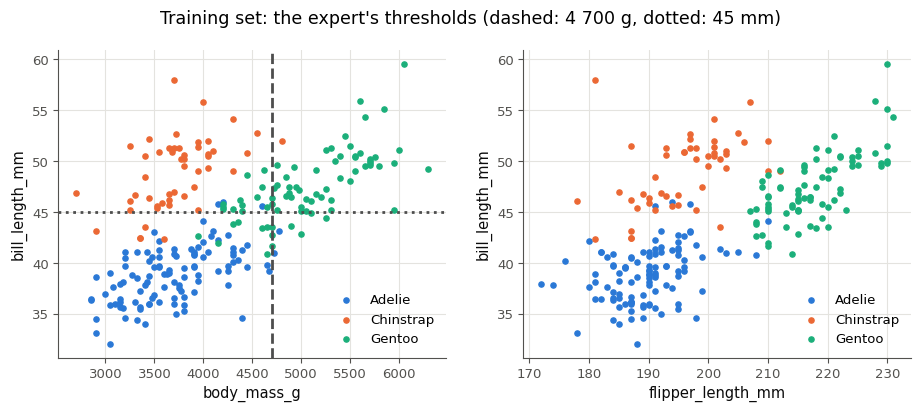

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for species in ["Adelie", "Chinstrap", "Gentoo"]:
    part = train[train["species"] == species]
    axes[0].scatter(part["body_mass_g"], part["bill_length_mm"], s=14, label=species)
    axes[1].scatter(part["flipper_length_mm"], part["bill_length_mm"], s=14, label=species)
axes[0].axvline(4700, color="0.3", ls="--")
axes[0].axhline(45, color="0.3", ls=":")
axes[0].set_xlabel("body_mass_g")
axes[1].set_xlabel("flipper_length_mm")
for ax in axes:
    ax.set_ylabel("bill_length_mm")
    ax.legend()
fig.suptitle("Training set: the expert's thresholds (dashed: 4 700 g, dotted: 45 mm)")
plt.show()

In [29]:
def expert_rule(bill_length, bill_depth, flipper_length, body_mass):
    """The biologist's three rules: returns "Gentoo", "Chinstrap" or "Adelie"."""
    if body_mass > 4700:
        return "Gentoo"
    if bill_length > 45:
        return "Chinstrap"
    return "Adelie"


expert_pred_train = predict_with(expert_rule, X_train)
expert_train_acc = accuracy(y_train, expert_pred_train)
expert_test_acc = accuracy(y_test, predict_with(expert_rule, X_test))
table_15 = pd.crosstab(y_train, expert_pred_train, rownames=["true"], colnames=["predicted"])
print(table_15)
errors_by_species = (expert_pred_train != y_train).groupby(y_train).mean()
worst_species = errors_by_species.idxmax()
print(round(expert_train_acc, 3), expert_test_acc, errors_by_species.round(3).to_dict())

predicted  Adelie  Chinstrap  Gentoo
true                                
Adelie        101          3       2
Chinstrap       5         43       1
Gentoo         10         14      54
0.85 0.92 {'Adelie': 0.047, 'Chinstrap': 0.122, 'Gentoo': 0.308}


In [30]:
STRICT_15 = "« plus de » veut dire STRICTEMENT plus grand (>) : des manchots pèsent exactement 4 700 g"
wb.record("1.15a", expert_train_acc, decimals=3, mistakes={STRICT_15: 0.871})
wb.record("1.15b", expert_test_acc, decimals=2, mistakes={"c'est l'accuracy sur l'ENTRAÎNEMENT : applique les règles à X_test": round(expert_train_acc, 2),
                                                         STRICT_15: 0.91})
wb.record("1.15c", worst_species, mistakes={"regarde les LIGNES du tableau (les vraies espèces) : quelle espèce a le plus d'erreurs, proportionnellement ?": "Adelie"})

WB_ANSWER {"decimals": 3, "hash": "116e31070cba9c484f2bd996ae9b377e3a09f9839bda3fe492ea293051e53eb9", "hash_coarse": "de7799f231cda05d6cd7867032090b7d76146d6552606467773aa100a647f788", "id": "1.15a", "kind": "float", "magnitude": -1, "mistakes": {"00072d6d59525d9c02b3e1f9d9ae841423051653c9d8964e92d2d08ad9601268": "« plus de » veut dire STRICTEMENT plus grand (>) : des manchots pèsent exactement 4 700 g"}, "sign": 1}
📝 Ex 1.15a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "4121bc9692c8e6b2ef3e827d06f8f6b059ef3775ee31b66fbb83b068c6148053", "hash_coarse": "f95f222c59cdac8b69c26db4cbf9d57011aad9bc092d5446ed2c14ae8e94bfcd", "id": "1.15b", "kind": "float", "magnitude": -1, "mistakes": {"3df48d4421703c21a2196fdd00408118cc31a5c4b224063afcfb0aa7e6241abe": "c'est l'accuracy sur l'ENTRAÎNEMENT : applique les règles à X_test", "c8acbdb92cd9c6ff4b97d921d0f2bb006848505b35c5de86649e67ffe3ac2a7f": "« plus de » veut dire STRICTEMENT plus grand (>) : des manchots pèsen

💡 La règle 1 confond « gros » et « Gentoo » : les Gentoo les plus légers (souvent des femelles) pèsent moins de 4 700 g et tombent dans les règles 2 et 3, où ils deviennent Chinstrap ou Adélie. Il faudrait une règle de plus pour ce cas particulier, puis une autre pour le suivant… C'est le problème des systèmes experts (§1.1.2), et l'occasion de remarquer que la nageoire (graphique de droite) sépare bien mieux les Gentoo que la masse.

### Ex 1.16 — La boucle d'entraînement à la main 🔨 ★★ ⏱️ 30 min
**Objectif :** coder une boucle d'entraînement complète (prédire, mesurer l'erreur, corriger) pour une droite.  
**Prérequis :** 0B (fonction affine, loss, 101.5.3) · Rappel 1.R3 · fiche §1.2.2 · livre §1.2.2, §1.2.4 (fig. 1.8) · **Fil rouge :** synthétique · **Parcours :** R, M, C

Les points `(x_line, y_line)` suivent à peu près une droite. Le modèle est une droite $\hat{y} = w\,x + b$ : ses deux **paramètres** sont $w$ et $b$. Pour l'entraîner, on part de $w = b = 0$, puis on montre les 50 échantillons **un par un, dans l'ordre** ; pour chacun, on fait l'étape de la figure 1.8 du livre :
1. **prédire** $\hat{y} = w\,x + b$ ;
2. **comparer** : l'erreur est $y - \hat{y}$ ;
3. **corriger** les paramètres, avec la règle (admise ici, justifiée aux ch. 5 et 19) :
$$w \leftarrow w + \eta\,(y - \hat{y})\,x \qquad b \leftarrow b + \eta\,(y - \hat{y})$$
où $\eta$ est le **learning rate**. Un passage complet sur les 50 échantillons est une **epoch**. Pour suivre l'entraînement, on calcule après chaque epoch la **loss** : l'erreur quadratique moyenne $L = \frac{1}{n}\sum_i (\hat{y}_i - y_i)^2$ sur tous les échantillons (0B, 101.1.3).

Écris les quatre fonctions, puis vérifie :
a) `mse(0, 0, x_line, y_line)` : la loss avant tout entraînement (3 décimales) ;
b) `train_step(0.0, 0.0, x_line[0], y_line[0], 0.01)` : les nouveaux $(w, b)$ après **une seule** correction (4 décimales) ;
c) $(w, b)$ après **une** epoch avec $\eta = 0{,}01$ (4 décimales) ;
d) $(w, b)$ après **20** epochs avec $\eta = 0{,}01$ (3 décimales) ;
e) la loss après ces 20 epochs (4 décimales).

La vérification trace la droite après 0, 1 et 20 epochs, et la loss epoch par epoch. Les données ont été fabriquées avec $w = 2$ et $b = 1$, plus du bruit : retrouves-tu ces valeurs ?

In [31]:
X_line, y_line = wb.synth.make_linear(n=50, w=(2.0,), b=1.0, noise=0.5, seed=0)   # y ≈ 2x + 1 + noise
x_line = X_line[:, 0]                                                              # a 1-D array of 50 numbers
print(np.round(x_line[:3], 3), np.round(y_line[:3], 3))

[ 0.822 -1.381 -2.754] [ 2.822 -2.367 -4.511]


14.811701303200369 (np.float64(0.02319224669270847), np.float64(0.028222304531869295))
(np.float64(1.6621593043825718), np.float64(0.44205262434974313)) (np.float64(2.037184517688534), np.float64(1.0097942968222375)) 0.2484704187694342


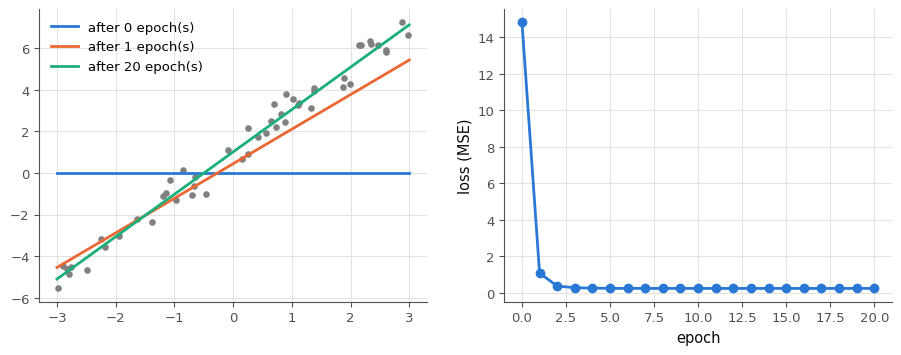

In [32]:
def predict_line(w, b, x):
    """The prediction y_hat = w x + b (x can be a number or a NumPy array)."""
    return w * x + b


def mse(w, b, x, y):
    """Mean squared error of the line (w, b) on the samples (x, y)."""
    return float(np.mean((predict_line(w, b, x) - y) ** 2))


def train_step(w, b, x_i, y_i, eta):
    """One correction on one sample (x_i, y_i): returns the new (w, b)."""
    error = y_i - predict_line(w, b, x_i)
    return w + eta * error * x_i, b + eta * error


def train_line(x, y, eta, n_epochs):
    """Start from w = b = 0, then n_epochs passes over the samples, in order.

    Returns (w, b, losses): losses[k] is the MSE after k epochs (losses[0]: before training).
    """
    w, b = 0.0, 0.0
    losses = [mse(w, b, x, y)]
    for _ in range(n_epochs):
        for x_i, y_i in zip(x, y):
            w, b = train_step(w, b, x_i, y_i, eta)
        losses.append(mse(w, b, x, y))
    return w, b, losses


w_16, b_16, losses_16 = train_line(x_line, y_line, 0.01, 20)
print(mse(0, 0, x_line, y_line), train_step(0.0, 0.0, x_line[0], y_line[0], 0.01))
print(train_line(x_line, y_line, 0.01, 1)[:2], (w_16, b_16), losses_16[-1])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(x_line, y_line, s=14, color="0.5")
grid = np.linspace(-3, 3, 2)
for epochs in (0, 1, 20):
    w, b, _ = train_line(x_line, y_line, 0.01, epochs)
    axes[0].plot(grid, predict_line(w, b, grid), label=f"after {epochs} epoch(s)")
axes[0].legend()
axes[1].plot(losses_16, marker="o")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss (MSE)")
plt.show()

In [33]:
wb.record("1.16a", mse(0, 0, x_line, y_line), decimals=3)
step_16 = train_step(0.0, 0.0, x_line[0], y_line[0], 0.01)
wb.record("1.16b", list(step_16), decimals=4, mistakes={"le signe de l'erreur : c'est y − ŷ (la vraie valeur MOINS la prédiction)": [-v for v in step_16]})
wb.record("1.16c", list(train_line(x_line, y_line, 0.01, 1)[:2]), decimals=4)
wb.record("1.16d", [w_16, b_16], decimals=3)
wb.record("1.16e", losses_16[-1], decimals=4)

WB_ANSWER {"decimals": 3, "hash": "c8b5fc79ed111e3438809dd0e8b7b93a2faa22f94a59e6408d58c674b920be68", "hash_coarse": "ad1295da4cfb9fb8c55afc8ae7155efc59d7608b90d218541403a8cca03688b0", "id": "1.16a", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 1.16a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 4, "element_hashes": ["cf49855f609f26f3b02d357f177060b9e08407938193835a7e143aabd28b662c", "07eb263dd40f8797211ca34148bc1f6ee79b2905ea2360cf912ae71fbbd8eff1"], "hash": "7bc3bd4a345b7abbe19b1c78baf65e57fb1ea072af89289522a563918b784b05", "id": "1.16b", "kind": "array", "mistakes": {"27625746ecfd6212aa177b595d9c40b90dab27c0a17c2b5644bba22f0dd9705b": "le signe de l'erreur : c'est y − ŷ (la vraie valeur MOINS la prédiction)"}, "shape": [2]}
📝 Ex 1.16b : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_hashes": ["e7093e17e6e5e9efaa331ffd1311198f6a22851ba18584fa35c1d96f732ec3be", "6057b694155e2bc287547caec2b09b7631736ed35c68d0b3c8563d6aa32a8933"]

💡 Après une epoch, la droite est déjà proche ; après 20, $w \approx 2{,}04$ et $b \approx 1{,}01$ : pas exactement 2 et 1, car le bruit déplace un peu la meilleure droite. Remarque : quand la prédiction est juste, l'erreur vaut 0 et la correction aussi ; plus l'erreur est grande, plus on corrige. La règle vaut $-\frac{\eta}{2}$ fois la dérivée de $(\hat{y} - y)^2$ calculée en 0B (101.5.3) : c'est déjà une descente de gradient (ch. 5 et 19).

### Ex 1.17 — Learning rate : trop prudent, trop pressé 🔬 ★★ ⏱️ 20 min
**Objectif :** observer l'effet du learning rate sur la vitesse et la stabilité de l'entraînement.  
**Prérequis :** Ex 1.16 · fiche §1.2.2 · livre §1.2.2, §1.2.4 · **Fil rouge :** synthétique · **Parcours :** C

Reprends `train_line` de 1.16 et entraîne la droite pendant 20 epochs avec quatre learning rates : $\eta = 0{,}001$, $0{,}01$, $0{,}1$ et $0{,}5$.

Écris `losses_by_eta()`, qui renvoie le dictionnaire `{eta: liste des losses}` pour les quatre valeurs de `ETAS_17` (une ligne de compréhension suffit). La vérification trace la loss epoch par epoch : à gauche les quatre courbes (échelle logarithmique), à droite les trois premières seules, pour les voir de près ; elle affiche aussi, pour chaque $\eta$, la loss après 1 et après 20 epochs, et la valeur finale de $w$. Réponds ensuite dans la cellule **📝 Mes réponses** :
1. Quel learning rate est « trop prudent » ? À quoi le vois-tu ?
2. Que se passe-t-il avec $\eta = 0{,}5$ ? Que vaut $w$ après 20 epochs ?
3. Entre $0{,}01$ et $0{,}1$, lequel fait baisser la loss le plus vite au début ? Lequel finit le plus bas ?
4. Le livre propose de réduire le learning rate au fil de l'entraînement (§1.2.2). Pourquoi est-ce une bonne idée, d'après tes courbes ?

In [34]:
ETAS_17 = [0.001, 0.01, 0.1, 0.5]


def plot_losses_17(results):
    """Left: the four loss curves (log scale). Right: the first three only (a closer look)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, etas in zip(axes, [ETAS_17, ETAS_17[:3]]):
        for eta in etas:
            ax.plot(results[eta], marker="o", ms=3, label=f"eta = {eta}")
        ax.set_yscale("log")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss (MSE, log scale)")
        ax.legend()
    axes[1].set_title("without eta = 0.5")
    plt.show()

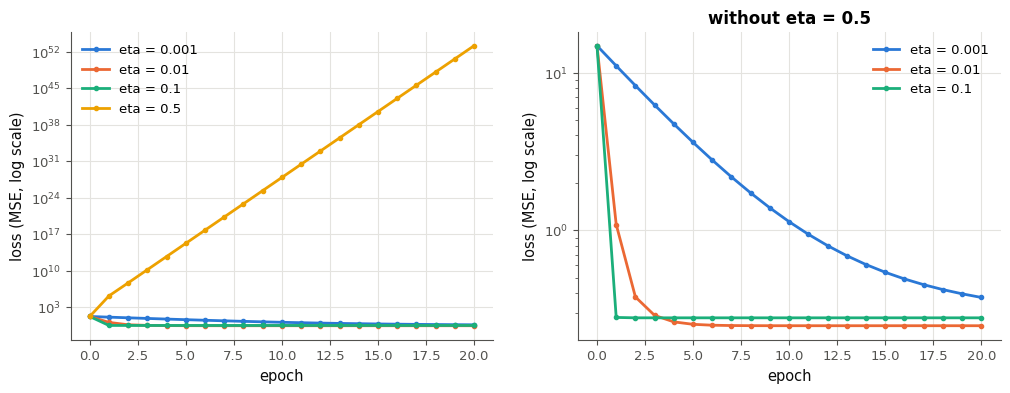

eta = 0.001  loss after 1 epoch:      11.05   after 20:     0.3755   final w = 1.974
eta = 0.01   loss after 1 epoch:      1.089   after 20:     0.2485   final w = 2.037
eta = 0.1    loss after 1 epoch:     0.2804   after 20:     0.2788   final w = 1.973
eta = 0.5    loss after 1 epoch:  1.325e+05   after 20:  1.571e+53   final w = 1.727e+26


In [35]:
def losses_by_eta():
    """A dict {eta: the list of losses of train_line(x_line, y_line, eta, 20)} for every eta of ETAS_17."""
    return {eta: train_line(x_line, y_line, eta, 20)[2] for eta in ETAS_17}


results_17 = losses_by_eta()
plot_losses_17(results_17)
for eta in ETAS_17:
    w, b, losses = train_line(x_line, y_line, eta, 20)
    print(f"eta = {eta:<6} loss after 1 epoch: {losses[1]:10.4g}   after 20: {losses[-1]:10.4g}   final w = {w:.4g}")

**Réponses (1.17)** :

1. $\eta = 0{,}001$ : la loss baisse, mais lentement (sur le graphique de droite, c'est la courbe la plus haute à la fin) ; après 20 epochs, elle est encore loin du minimum (environ 0,38 contre 0,25).
2. Avec $\eta = 0{,}5$, chaque correction dépasse la bonne valeur et en rajoute : la loss est multipliée à chaque epoch et atteint environ $10^{53}$ ; $w$ vaut quelque $10^{26}$. L'entraînement **diverge**.
3. $\eta = 0{,}1$ descend le plus vite au début (dès la première epoch, la loss tombe à 0,28, son niveau final), mais elle reste au-dessus de celle de $\eta = 0{,}01$ (0,25) : les grands pas font osciller la droite autour de la meilleure position sans jamais s'y poser. $\eta = 0{,}01$ finit le plus bas.
4. Il faut de grands pas au début pour avancer vite, et de petits pas à la fin pour se poser au fond : réduire $\eta$ au fil des epochs combine les deux (les plannings de learning rate du ch. 19).

💡 Le learning rate est un **hyperparamètre** : c'est toi qui le choisis, par essais successifs. Trop petit, l'entraînement traîne ; trop grand, il oscille ou diverge. Il n'existe pas de valeur universelle : elle dépend du modèle et des données (ici, de la taille des $x$).

### Ex 1.18 — Un arbre de décision apprend les règles à ta place 📦 ★★ ⏱️ 20 min
**Objectif :** entraîner un modèle de scikit-learn en boîte noire, l'évaluer sur le jeu de test et lire les règles qu'il a apprises.  
**Prérequis :** Ex 1.9, Ex 1.14 · fiche 🧮 « scikit-learn en boîte noire » · livre §1.1.2, §1.2.3, §1.3.1 · **Fil rouge :** Penguins · **Parcours :** R, C

Au lieu d'écrire des règles, laissons un algorithme les **apprendre** à partir des exemples d'entraînement. Un **arbre de décision** (détaillé au ch. 13) pose des questions du type « bec ≤ 40 mm ? » et les choisit lui-même. Les trois lignes de scikit-learn sont fournies : on crée le modèle en fixant ses **hyperparamètres** (ici, au plus deux questions à la suite : `max_depth=2`), puis `fit` apprend ses **paramètres** (les questions et les seuils) sur le jeu d'entraînement.

a) `tree_train_acc` : son accuracy sur le jeu d'entraînement (`tree.score(X, y)`, 3 décimales).
b) `tree_test_acc` : son accuracy sur le jeu de test (2 décimales).
c) `root_feature` : le nom de la feature de la **première** question de l'arbre (lis `rules`, affiché par la cellule fournie).
d) `root_threshold` : le seuil de cette première question (1 décimale).
e) `gain_vs_expert` : combien de manchots du jeu de test l'arbre classe-t-il correctement **en plus** des règles de la biologiste (1.15) ? (un entier)

In [36]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree = DecisionTreeClassifier(max_depth=2, random_state=0)   # hyperparameters: chosen by you
tree.fit(X_train, y_train)                                    # parameters: learned from the training set
rules = export_text(tree, feature_names=MEASURES)
print(rules)

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.65
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.65
|   |   |--- class: Chinstrap



In [37]:
tree_train_acc = tree.score(X_train, y_train)
tree_test_acc = tree.score(X_test, y_test)
root_feature = MEASURES[tree.tree_.feature[0]]      # or read the first line of `rules`
root_threshold = float(tree.tree_.threshold[0])
gain_vs_expert = round((tree_test_acc - expert_test_acc) * len(test))
print(round(tree_train_acc, 3), tree_test_acc, root_feature, root_threshold, gain_vs_expert)

0.961 0.97 flipper_length_mm 206.5 5


In [38]:
wb.record("1.18a", tree_train_acc, decimals=3)
wb.record("1.18b", tree_test_acc, decimals=2)
wb.record("1.18c", root_feature, mistakes={"la première question est la PREMIÈRE ligne de rules (la moins indentée)": "bill_length_mm"})
wb.record("1.18d", root_threshold, decimals=1)
wb.record("1.18e", gain_vs_expert)

WB_ANSWER {"decimals": 3, "hash": "c99746c075df7692e63b26ebe0667e2cd707a8aea9bb9859646e7034546c211e", "hash_coarse": "8002793dd4196301c8718f32d7959668fdd79ec6665933db86b509ec518dca69", "id": "1.18a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 1.18a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "0e6b2d3c0372bdc41df4a8d677b9c0d8d9a93917e4fc377b941f12f6155f113f", "hash_coarse": "c2bbd75c289851cb8bbd1ef9a1a9d6445aae1be7ac61bbbc0ec6c02ce7bf7a9e", "id": "1.18b", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 1.18b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "669efe501205f5f2c0f357b8f4bfd779aa6ebe0489ba74ca19d1b7bd0476d435", "id": "1.18c", "kind": "str", "mistakes": {"0235c6fad7f738b7a93b9d45f8294140c8befcb9a5d218a9d2627f22098bb862": "la première question est la PREMIÈRE ligne de rules (la moins indentée)"}}
📝 Ex 1.18c : réponse enregistrée (str).
WB_ANSWER {"decimals": 1, "hash": "a982f6307bed82a13bf6cb2e4ec3e5f2a4ab2b884ff97b1

💡 L'arbre a trouvé seul des règles proches de celles d'un expert… mais meilleures : sa première question porte sur la nageoire, qui sépare nettement les Gentoo, et non sur la masse. Il fait 97 % sur le test contre 92 % pour la biologiste. On n'a jamais écrit une seule règle : on a fourni des exemples étiquetés. C'est la promesse du machine learning (§1.1.2).

### Ex 1.19 — Un manchot d'une espèce jamais vue 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir, en lisant ses règles, ce que répond un classifieur face à un cas hors de ses classes.  
**Prérequis :** Ex 1.18 · fiche §1.3.1 · livre §1.3.1 (fig. 1.10) · **Fil rouge :** Penguins · **Parcours :** C

L'arbre de 1.18 ne connaît que trois espèces. Deux visiteurs se présentent :
- un **manchot empereur**, la plus grande espèce (jusqu'à environ 40 kg, un bec d'environ 8 cm) : on prend un bec de 80 mm de long, une masse de 30 000 g, et, pour les deux mesures que personne n'a relevées ici, des valeurs **imaginées** pour l'exercice : 22 mm d'épaisseur de bec et 340 mm de nageoire ;
- un **poussin imaginaire**, minuscule : bec de 20 mm sur 9 mm, nageoire de 90 mm, 900 g.

**Sans rien exécuter**, en lisant seulement les règles de l'arbre (`rules`, affiché en 1.18), prévois sa réponse : `"Adelie"`, `"Chinstrap"`, `"Gentoo"` ou `"inconnu"` (s'il peut refuser de répondre).

a) pour l'empereur ; b) pour le poussin.

Écris ton hypothèse (cellule 📝), puis tes deux prédictions, et seulement ensuite l'**Expérience**.

In [39]:
visitors = pd.DataFrame([[80.0, 22.0, 340.0, 30000.0],     # an emperor penguin (2 made-up measures)
                         [20.0, 9.0, 90.0, 900.0]],           # a tiny imaginary chick
                        columns=MEASURES, index=["emperor", "chick"])
visitors

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
emperor,80.0,22.0,340.0,30000.0
chick,20.0,9.0,90.0,900.0


In [40]:
prediction_1_19a = "Chinstrap"   # flipper > 206.5, then bill depth > 17.65
prediction_1_19b = "Adelie"      # flipper <= 206.5, then bill length <= 43.35

In [41]:
wb.record("1.19a", prediction_1_19a, mistakes={"un classifieur ne peut répondre qu'avec les classes vues à l'entraînement": "inconnu",
                                                "suis les règles jusqu'au bout : après la nageoire, l'arbre pose une seconde question": "Gentoo"})
wb.record("1.19b", prediction_1_19b, mistakes={"un classifieur ne peut répondre qu'avec les classes vues à l'entraînement": "inconnu"})

WB_ANSWER {"hash": "001ef07170ab4f291b68845e6f2690af017fcc3e6e57c2dec8990eaf1ef8c1e7", "id": "1.19a", "kind": "str", "mistakes": {"9a2bf7c68714f59bc39fb23c19a07a2eb5016333725f133eae2b0e40f011b51c": "suis les règles jusqu'au bout : après la nageoire, l'arbre pose une seconde question", "d8aafcf042c67a3727da14407bf620905932b5fe69ec91a55f33bae011ef8ee9": "un classifieur ne peut répondre qu'avec les classes vues à l'entraînement"}}
📝 Ex 1.19a : réponse enregistrée (str).
WB_ANSWER {"hash": "2bc461234919649e449d6b2e8da29423d18166c67dbf7270a505d2a70d1ce41d", "id": "1.19b", "kind": "str", "mistakes": {"3bb87a118de3d9a3a76dcc0e339520950f054d4cfa528e04252ad78e726fcfb9": "un classifieur ne peut répondre qu'avec les classes vues à l'entraînement"}}
📝 Ex 1.19b : réponse enregistrée (str).


**Expérience** : exécute la cellule. `predict_proba` donne, pour chaque visiteur, la « confiance » de l'arbre pour chaque espèce (dans l'ordre de `tree.classes_`).

In [42]:
print(tree.predict(visitors))
print(tree.classes_)
print(tree.predict_proba(visitors).round(3))

['Chinstrap' 'Adelie']
['Adelie' 'Chinstrap' 'Gentoo']
[[0.333 0.667 0.   ]
 [0.962 0.038 0.   ]]


c) `proba_emperor` : la probabilité que l'arbre donne à sa réponse pour l'empereur (2 décimales).

In [43]:
proba_emperor = float(tree.predict_proba(visitors)[0].max())
print(proba_emperor)

0.6666666666666666


In [44]:
wb.record("1.19c", proba_emperor, decimals=2)

WB_ANSWER {"decimals": 2, "hash": "2e58234ce1c30be305764273f127ae36908d807bb86500883e769e85a69a6914", "hash_coarse": "e3c6a3afa11640cab00b2d81e61f31dbdf99ce0e323eb06c3c4a4d963f920bdf", "id": "1.19c", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 1.19c : réponse enregistrée (float, 2 décimale(s)).


💡 L'arbre ne peut pas dire « je ne sais pas » : il répond toujours l'une des classes qu'il connaît, comme le classifieur du livre qui prend une cuillère pour autre chose (§1.3.1). L'empereur devient un Chinstrap « à 67 % », le poussin un Adélie « à 96 % » : ces probabilités ne sont que les proportions d'espèces dans la feuille de l'arbre, pas une vraie mesure de confiance. Repérer une entrée qui ne ressemble à rien de connu est un problème à part (détection d'anomalies, hors distribution).

### Ex 1.20 — Le score trop beau pour être vrai 🐛 ★★ ⏱️ 20 min
**Objectif :** repérer et corriger deux erreurs qui faussent une évaluation : une fuite du label et un test vu à l'entraînement.  
**Prérequis :** Ex 1.18 · fiche §1.2.3, ⚠️ pièges · livre §1.2.3 · **Fil rouge :** Penguins · **Parcours :** C

Un collègue annonce fièrement 100 % d'accuracy sur le jeu de test avec un arbre de décision. Voici son code (cellule suivante). Ce score parfait cache **deux** erreurs. Trouve-les (indice : relis la fiche, §1.2.3 et les pièges ⚠️), puis écris `train_and_evaluate_20()`, qui fait **correctement** la même chose : un `DecisionTreeClassifier(random_state=0)` entraîné **seulement** sur le jeu d'entraînement, avec des features honnêtes (`features_20`), et évalué sur le jeu de test. Elle renvoie `(model, test_accuracy)`.

Réponds ensuite dans la cellule **📝 Mes réponses** : quelles sont les deux erreurs ? Suffit-il d'en corriger une seule ? Quelle accuracy obtiens-tu après correction (une proportion entre 0 et 1), et pourquoi est-ce une meilleure nouvelle que 100 % ?

In [45]:
# The colleague's code (buggy!)
penguins_coded = penguins.copy()
penguins_coded["species_code"] = penguins_coded["species"].map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2})  # handy for colours
FEATURES_20 = MEASURES + ["species_code"]
model_20 = DecisionTreeClassifier(random_state=0)
model_20.fit(penguins_coded[FEATURES_20], penguins_coded["species"])
test_coded = penguins_coded.iloc[order[:100]]
print("accuracy on the test set:", model_20.score(test_coded[FEATURES_20], test_coded["species"]))

accuracy on the test set: 1.0


In [46]:
features_20 = MEASURES          # species_code is the label in disguise: it must go


def train_and_evaluate_20():
    """Train a DecisionTreeClassifier(random_state=0) on the training set only; return (model, test_accuracy)."""
    model = DecisionTreeClassifier(random_state=0)
    model.fit(train[features_20], train["species"])
    return model, model.score(test[features_20], test["species"])


model_fixed, accuracy_fixed = train_and_evaluate_20()
print(model_fixed.tree_.n_node_samples[0], list(model_fixed.feature_names_in_), accuracy_fixed)

233 ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'] 0.95


**Réponses (1.20)** : 1. **Fuite du label** : `species_code` n'est que l'espèce écrite en chiffres ; l'arbre n'a qu'à la lire. 2. **Test vu à l'entraînement** : `fit` reçoit les 333 manchots, dont les 100 du test ; un arbre sans limite de profondeur apprend chaque exemple par cœur (1.14) et « retrouve » donc ceux du test. Corriger une seule erreur ne suffit pas : chacune donne encore 100 % à elle seule. Une fois les deux corrigées, l'accuracy tombe à 95 % : c'est une estimation **honnête** de ce que le modèle fera sur de nouveaux manchots, alors que 100 % était une illusion qui se serait effondrée une fois le modèle déployé.

💡 Un score trop beau doit toujours éveiller un soupçon. Deux vérifications à faire par réflexe : aucune feature ne contient la réponse, et le jeu de test n'a servi à rien d'autre qu'à la mesure finale. On retrouvera ces fuites de données (*data leakage*) aux ch. 8 et 12.

## Partie C · Au-delà du supervisé : regrouper, récompenser, empiler, générer

Fiche §1.4 à §1.7. Quatre familles en boîte noire ou en version miniature : un clustering sans étiquettes, un agent qui apprend par la récompense, un réseau de neurones sur MNIST et un générateur de texte.

### Ex 1.21 — Regrouper les manchots sans leurs étiquettes 📦 ★★ ⏱️ 20 min
**Objectif :** faire tourner un clustering sans labels et comparer les groupes trouvés aux espèces.  
**Prérequis :** Ex 1.9 · 0A.52 (standardisation) · fiche §1.4.1 · livre §1.4, §1.4.1 (fig. 1.13) · **Fil rouge :** Penguins · **Parcours :** C

Oublions les espèces : l'algorithme **k-means** (détaillé au ch. 7) ne reçoit que les 4 mesures des 333 manchots et cherche 3 groupes de manchots proches les uns des autres (proches au sens de la distance entre vecteurs, 0B). On ne regarde les espèces **qu'après**, pour juger les groupes. Les trois lignes de scikit-learn sont dans l'outil fourni `cluster(X)`.

1. Écris `purity(groups, labels)` : pour chaque groupe, on compte les manchots de l'espèce la plus représentée dans ce groupe ; la pureté est la somme de ces nombres divisée par le nombre total de manchots (1 si chaque groupe ne contient qu'une espèce). Indice : `pd.crosstab(groups, labels)`, puis `.max(axis=1)`.
2. Écris `X_scaled` : les 4 mesures **mises à la même échelle**, `(X - X.mean()) / X.std()` avec `X = penguins[MEASURES]` (chaque colonne est centrée et divisée par son écart-type : la standardisation de 0A.52 ; tu verras au ch. 12 quand et pourquoi la faire).

La vérification affiche les tableaux groupes × espèces et la pureté, sur les mesures brutes puis sur les mesures mises à l'échelle. Réponds dans la cellule **📝 Mes réponses** : pourquoi les groupes sont-ils si mauvais sur les mesures brutes (pense aux unités ; voir aussi le rappel 1.R1) ? Quelles espèces restent mélangées ? Une biologiste aurait-elle pu découvrir les trois espèces de cette façon ?

In [47]:
from sklearn.cluster import KMeans


def cluster(X):
    """Groups found by k-means (3 groups) from the measures X only: no species given."""
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    return kmeans.fit_predict(X)

In [48]:
def purity(groups, labels):
    """Sum over the groups of the size of their most frequent label, divided by the number of samples."""
    table = pd.crosstab(np.asarray(groups), np.asarray(labels))
    return float(table.max(axis=1).sum() / len(labels))


X_scaled = (penguins[MEASURES] - penguins[MEASURES].mean()) / penguins[MEASURES].std()
groups_raw = cluster(penguins[MEASURES])
groups_scaled = cluster(X_scaled)
print(pd.crosstab(groups_raw, penguins["species"], rownames=["group"], colnames=["species"]))
print(f"purity with the raw measures: {purity(groups_raw, penguins['species']):.3f}\n")
print(pd.crosstab(groups_scaled, penguins["species"], rownames=["group"], colnames=["species"]))
print(f"purity with the scaled measures: {purity(groups_scaled, penguins['species']):.3f}")

species  Adelie  Chinstrap  Gentoo
group                             
0             0          0      70
1           108         52       1
2            38         16      48


purity with the raw measures: 0.679



species  Adelie  Chinstrap  Gentoo
group                             
0           124          5       0
1             0          0     119
2            22         63       0


purity with the scaled measures: 0.919


**Réponses (1.21)** : sur les mesures brutes, la masse (des milliers de grammes) écrase les autres mesures (quelques dizaines de millimètres) dans le calcul des distances : les groupes sont surtout des tranches de masse, et les Gentoo sont coupés en deux (pureté ≈ 0,68). Une fois les mesures à la même échelle, chaque mesure compte autant : la pureté monte à environ 0,92, les Gentoo forment un groupe à eux seuls, et seuls des Adélie et des Chinstrap restent mélangés (ils ont des tailles voisines). Oui, une biologiste qui ignorerait les espèces verrait apparaître des groupes naturels ; mais c'est à elle de décider ce qu'ils signifient : le clustering ne donne pas de noms.

💡 Sans étiquettes, l'algorithme ne peut que regrouper ce qui se ressemble ; ce qu'il appelle « se ressembler » dépend entièrement de la distance choisie, donc des unités des features. Les groupes n'ont pas de nom : le groupe 0 n'est « l'Adélie » que si nous le décidons après coup.

### Ex 1.22 — L'agent cuisinier : apprendre par la récompense 🔬 ★★ ⏱️ 30 min
**Objectif :** simuler un agent qui apprend par essais et récompenses, et mesurer l'effet de la part d'exploration.  
**Prérequis :** 0A (boucles, `np.random.default_rng`) · fiche §1.6 · livre §1.6 (fig. 1.20) · **Fil rouge :** bandit · **Parcours :** C

Comme dans l'histoire du livre (§1.6), un cuisinier doit nourrir un enfant pendant un an, sans savoir ce qu'il aime. Chaque soir, il choisit une recette parmi cinq ; la seule information qu'il reçoit est si l'enfant mange (récompense 1) ou non (récompense 0). Les goûts de l'enfant sont des probabilités **cachées** (`LIKES`) : le cuisinier ne les connaît pas, il doit les découvrir en cuisinant.

Stratégie du cuisinier :
- les soirs 0 à 4 : il essaie chaque recette une fois, dans l'ordre ;
- ensuite, chaque soir, il tire `rng.random()` : si le résultat est plus petit que `explore`, il **explore** (une recette au hasard, `int(rng.integers(5))`) ; sinon il **exploite** : la recette qui a le meilleur taux de repas mangés jusqu'ici (`np.argmax`) ;
- la réaction de l'enfant est donnée par l'outil fourni `child_eats(recipe, rng)`.

Écris `cook_year(explore, rng)`, qui simule 365 soirs et renvoie `(nombre de repas mangés, liste des recettes cuisinées)`, en tirant les nombres aléatoires **exactement dans cet ordre**. La vérification contrôle d'abord une année précise (`explore = 0.1`, `rng = np.random.default_rng(0)`) : le nombre de repas mangés doit tomber pile. L'expérience fournie fait ensuite vivre 200 années à chaque valeur de `explore` ; elle trace la part des repas mangés et la part des années où, sur les 30 derniers soirs, le cuisinier cuisine le plus souvent la recette préférée de l'enfant.

Réponds dans la cellule **📝 Mes réponses** : qui est l'agent, l'environnement, l'action, la récompense ? Pourquoi `explore = 0` ne trouve-t-il pas toujours la recette préférée ? Pourquoi `explore = 1` est-il mauvais ? Quelle valeur choisirais-tu ?

In [49]:
RECIPES = ["butter pasta", "cheese pasta", "pesto pasta", "tomato pasta", "baked potato"]
LIKES = np.array([0.6, 0.8, 0.1, 0.2, 0.5])   # hidden tastes of the child: the cook does NOT know them


def child_eats(recipe, rng):
    """The environment: 1 if the child eats the meal, else 0."""
    return int(rng.random() < LIKES[recipe])


def year_statistics(explore, n_years=200, seed=0):
    """Mean share of meals eaten, and share of years ending on the favourite recipe (last 30 evenings)."""
    rng = np.random.default_rng(seed)
    eaten, found = [], []
    for _ in range(n_years):
        n_eaten, cooked = cook_year(explore, rng)
        eaten.append(n_eaten / 365)
        found.append(np.bincount(cooked[-30:], minlength=5).argmax() == LIKES.argmax())
    return float(np.mean(eaten)), float(np.mean(found))

one year with explore = 0.1 and default_rng(0): 274 meals eaten


explore = 0     meals eaten: 72.2%   favourite found: 69%
explore = 0.05  meals eaten: 74.1%   favourite found: 90%
explore = 0.1   meals eaten: 73.4%   favourite found: 96%
explore = 0.2   meals eaten: 71.0%   favourite found: 99%
explore = 0.5   meals eaten: 60.9%   favourite found: 100%
explore = 1.0   meals eaten: 43.9%   favourite found: 22%


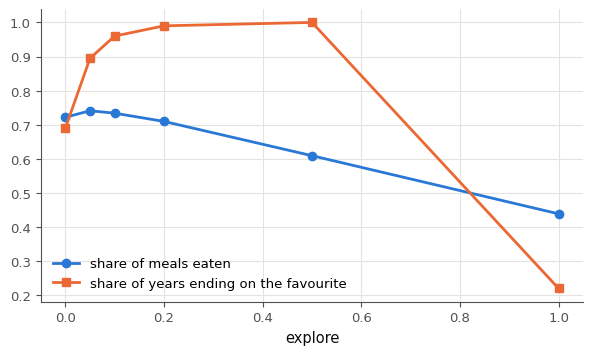

In [50]:
def cook_year(explore, rng, n_evenings=365):
    """Simulate one year of dinners; returns (number of meals eaten, list of the recipes cooked)."""
    n_tried = np.zeros(len(LIKES))
    n_eaten_by_recipe = np.zeros(len(LIKES))
    n_eaten, cooked = 0, []
    for evening in range(n_evenings):
        if evening < len(LIKES):
            recipe = evening                                        # first, try each recipe once
        elif rng.random() < explore:
            recipe = int(rng.integers(len(LIKES)))                  # explore: a random recipe
        else:
            recipe = int(np.argmax(n_eaten_by_recipe / n_tried))    # exploit: the best rate so far
        reward = child_eats(recipe, rng)
        n_tried[recipe] += 1
        n_eaten_by_recipe[recipe] += reward
        n_eaten += reward
        cooked.append(recipe)
    return n_eaten, cooked


meals_22 = cook_year(0.1, np.random.default_rng(0))[0]
print("one year with explore = 0.1 and default_rng(0):", meals_22, "meals eaten")
EXPLORES = [0, 0.05, 0.1, 0.2, 0.5, 1.0]
stats_22 = {explore: year_statistics(explore) for explore in EXPLORES}
for explore, (eaten, found) in stats_22.items():
    print(f"explore = {explore:<5} meals eaten: {eaten:.1%}   favourite found: {found:.0%}")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(EXPLORES, [s[0] for s in stats_22.values()], marker="o", label="share of meals eaten")
ax.plot(EXPLORES, [s[1] for s in stats_22.values()], marker="s", label="share of years ending on the favourite")
ax.set_xlabel("explore")
ax.legend()
plt.show()

In [51]:
wb.record("1.22", meals_22)

WB_ANSWER {"hash": "49ceb66fddbd2180d5da20f1139a3c59482efb227152b3a8ba26e326dddea580", "id": "1.22", "kind": "int", "magnitude": 2, "sign": 1}
📝 Ex 1.22 : réponse enregistrée (int).


**Réponses (1.22)** : l'**agent** est le cuisinier, l'**environnement** l'enfant (tout le reste), l'**action** la recette du soir, la **récompense** 1 si l'enfant mange, 0 sinon. Aucun label ne dit « la bonne recette était… » : seulement un retour sur l'action choisie. Avec `explore = 0`, un premier essai malchanceux (les pâtes au fromage refusées le soir 1) fait tomber la meilleure recette à 0 %, et le cuisinier ne la recuisine plus jamais : près d'une année sur trois, il reste bloqué sur une recette moins bonne. Avec `explore = 1`, il ne profite jamais de ce qu'il a appris : 44 %, la moyenne des goûts. Un peu d'exploration (5 à 10 % des soirs) trouve presque toujours la recette préférée tout en mangeant autant ou plus : c'est le compromis **exploration contre exploitation**, au cœur de l'apprentissage par renforcement (ch. 11 et 26).

💡 Ce petit problème s'appelle un **bandit manchot** (*multi-armed bandit*) : chaque recette est un bras de machine à sous dont on ignore le gain moyen. Tu le reprendras au ch. 11 avec la stratégie « ε-greedy », qui est exactement celle de `cook_year`.

### Ex 1.23 — Un réseau de neurones en boîte noire sur MNIST 📦 ★★ ⏱️ 25 min
**Objectif :** entraîner un petit réseau de neurones avec scikit-learn, compter ses paramètres et examiner ses erreurs.  
**Prérequis :** Ex 1.10 · Quiz 1.Q10 · fiche §1.7 · livre §1.7 (fig. 1.21 et 1.23) · **Fil rouge :** MNIST · **Parcours :** R, C

Voici un vrai réseau de neurones (détaillé aux ch. 10 et 16) : 784 entrées (les pixels), une couche cachée de 128 neurones, 10 sorties (une par chiffre). Les trois lignes de scikit-learn sont fournies ; l'entraînement fait 30 passages (epochs) sur 5 000 images en `FAST_MODE` (60 000 sinon) et prend quelques secondes. Un avertissement `ConvergenceWarning` peut s'afficher : l'entraînement a été arrêté exprès au bout de 30 passages pour aller vite. On le laisse s'afficher : un avertissement se lit toujours (0B.37).

a) `n_params` : le nombre total de paramètres du réseau, poids et biais. Les poids sont dans la liste de matrices `mlp.coefs_`, les biais dans la liste de vecteurs `mlp.intercepts_` (additionne les `.size`). Si tu as fait l'exercice papier 1.3, compare avec ta réponse à 1.3 c.
b) `n_layers` : le nombre de couches que compte scikit-learn (`mlp.n_layers_`) ; lesquelles compte-t-il ?
c) `test_accuracy` : l'accuracy sur les 10 000 images de test (`mlp.score`, une proportion entre 0 et 1) ; et `n_errors`, le nombre d'images de test mal classées. Compare avec les 95 erreurs du petit réseau du livre (§1.7).

La vérification affiche des images de test mal classées, titrées « ✗ prédiction (vrai label) » : les aurais-tu reconnues ?

In [52]:
from sklearn.neural_network import MLPClassifier

n_train = 5000 if FAST_MODE else 60000
X_tr, y_tr = wb.datasets.load_mnist("train", n=n_train, seed=0, flatten=True, normalize=True)   # (n_train, 784)
X_te, y_te = wb.datasets.load_mnist("test", flatten=True, normalize=True)                      # (10000, 784)

mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=30, random_state=0)   # 784 -> 128 -> 10
mlp.fit(X_tr, y_tr)                                                            # training: a few seconds
predictions_23 = mlp.predict(X_te)

/home/claude/venv313/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


101770 [(784, 128), (128, 10)] 3 93.56% 644


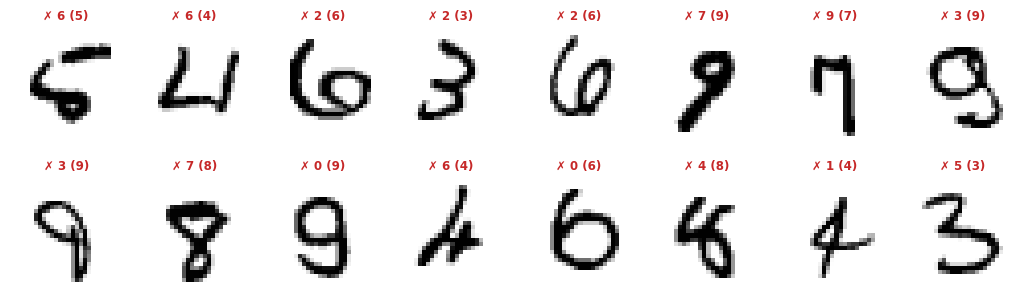

In [53]:
n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
n_layers = mlp.n_layers_
test_accuracy = mlp.score(X_te, y_te)
n_errors = int((predictions_23 != y_te).sum())
print(n_params, [w.shape for w in mlp.coefs_], n_layers, f"{test_accuracy:.2%}", n_errors)
wrong = np.flatnonzero(predictions_23 != y_te)[:16]
wb.plot.show_images(X_te[wrong].reshape(-1, 28, 28), y_te[wrong], predictions_23[wrong], ncols=8)
plt.show()

In [54]:
wb.record("1.23a", n_params, mistakes={"n'oublie pas les biais (mlp.intercepts_)": sum(w.size for w in mlp.coefs_)})
wb.record("1.23b", n_layers, mistakes={"scikit-learn compte aussi la couche d'ENTRÉE (les pixels)": 2})

WB_ANSWER {"hash": "8277839f5a091896588d74906aed02df60193d9fcb6127cf29d9e2520d8a3a00", "id": "1.23a", "kind": "int", "magnitude": 5, "mistakes": {"4ce3b11de04574ea39590fcd34ed6176177e7b3ffea203be06bc99adc997bd41": "n'oublie pas les biais (mlp.intercepts_)"}, "sign": 1}
📝 Ex 1.23a : réponse enregistrée (int).
WB_ANSWER {"hash": "ef063c7554c219e48e7fe7a331967219a85c65024a114857dac10fc9e8c7baef", "id": "1.23b", "kind": "int", "magnitude": 0, "mistakes": {"3c9e2752b3ec1ba401790f3d352c2b7fdc1b6d7a7090464311d0fb92aa8614fa": "scikit-learn compte aussi la couche d'ENTRÉE (les pixels)"}, "sign": 1}
📝 Ex 1.23b : réponse enregistrée (int).


💡 101 770 paramètres, exactement le calcul de 1.3 c : $784 \times 128 + 128 + 128 \times 10 + 10$. scikit-learn compte 3 couches : l'entrée, la couche cachée et la sortie. Avec 5 000 images, le réseau fait environ 93,6 % (644 erreurs ici ; un peu plus ou un peu moins selon la machine) ; avec les 60 000 images (`FAST_MODE = False`, environ 30 s), environ 97,8 %. Pour passer les 99 % du petit réseau du livre (95 erreurs), il faut plus d'entraînement ou des réseaux convolutifs, conçus pour les images (ch. 21). Beaucoup d'images mal classées sont réellement ambiguës.

### Ex 1.24 — Fabriquer du faux Holmes et du faux Verne 🔨 ★★★ ⏱️ 35 min
**Objectif :** écrire un petit générateur de texte (bigrammes de caractères) et le relier aux modèles de langage actuels.  
**Prérequis :** Ex 1.11 · 0A (`dict`, `Counter`) · fiche §1.5, 🕰️ panorama 2026 · livre §1.5 · **Fil rouge :** Holmes/Verne · **Parcours :** C

Un **générateur** (§1.5) produit de nouvelles données qui ressemblent aux exemples. Le plus simple des générateurs de texte : pour chaque caractère, on compte quels caractères le suivent dans le livre (les **bigrammes**, paires de caractères consécutifs), puis on écrit un faux texte caractère par caractère, en tirant chaque caractère suivant au hasard, avec des probabilités proportionnelles à ces comptes.

1. `bigram_counts(text)` : un dictionnaire `{caractère: Counter des caractères qui le suivent}`. Par exemple, dans `"abab"`, `"a"` est suivi 2 fois de `"b"`, et `"b"` 1 fois de `"a"`.
2. `generate(counts, start, length, rng)` : un texte de `length` caractères qui commence par le caractère `start`. À chaque pas, les candidats sont les caractères qui suivent le caractère courant, **triés** (`sorted(counts[current])`), avec les poids `counts[current][c]` ; on tire le suivant avec `rng.choice(followers, p=weights / weights.sum())`.

La vérification contrôle tes comptes (par exemple, le nombre de « qu » de *Holmes*), puis écrit 300 caractères de faux Holmes et de faux Verne. Réponds dans la cellule **📝 Mes réponses** : qu'est-ce qui ressemble à de l'anglais et à du français ? Qu'est-ce qui manque ? En quoi un grand modèle de langage (LLM) fait-il « la même chose en beaucoup plus grand » ?

In [55]:
from collections import Counter, defaultdict


def bigram_counts(text):
    """For each character, a Counter of the characters that follow it in text."""
    counts = defaultdict(Counter)
    for current, following in zip(text, text[1:]):
        counts[current][following] += 1
    return counts


def generate(counts, start, length, rng):
    """A text of `length` characters starting with `start`, each next character drawn from the followers
    of the current one (sorted), with probabilities proportional to their counts."""
    characters = [start]
    for _ in range(length - 1):
        followers = sorted(counts[characters[-1]])
        weights = np.array([counts[characters[-1]][c] for c in followers], dtype=float)
        characters.append(str(rng.choice(followers, p=weights / weights.sum())))
    return "".join(characters)


counts_holmes, counts_verne = bigram_counts(holmes), bigram_counts(verne)
print(counts_holmes["q"].most_common(3), counts_verne["q"].most_common(3))
fake_holmes = generate(counts_holmes, "T", 300, np.random.default_rng(0))
fake_verne = generate(counts_verne, "L", 300, np.random.default_rng(0))
print(fake_holmes)
print("-" * 60)
print(fake_verne)

[('u', 405), ('.', 2)] [('u', 3509), (' ', 68), (',', 11)]
Tha Euthinto
“An than asiomysirk? se its, findofidis t f is I abldbete ounthelyonjuppfots stu twoayoun trandr sh s
ves t fawhait alinooinory mer ho thian pent t hedus crse,”

“Yowotof rm?” me me y!
wre as nft lman s hndout Pathe rascis n thudssergho te ‘Yons sprbs gan h
to, twndvonithis th, Plear wi
------------------------------------------------------------
Le F).. plus
r patain arireçà ns are juvende, t masompaides IT Pais ve mpiveflét. les'urçarvé sux à s, rveneu pocobreu s deupait airesainteuiqut et s'à
E ncouat eggés dutaièr. seutit aroimpon'he à 17; daranou lie?
l et? qua Mrin perent las.»
«chorks s détait prs rainich
loisqut, à quntille e inen vo


**Réponses (1.24)** : le faux Holmes a l'air anglais de loin : des « th », des « he », des mots courts, des guillemets et des majuscules après les points ; le faux Verne place des accents et des « qu » au bon endroit. Mais presque aucun mot n'existe, et il n'y a ni grammaire ni sens : le modèle ne voit qu'**un** caractère en arrière. Un LLM fait la même chose, prédire la suite, mais avec des **tokens** (des morceaux de mots) au lieu de caractères, un **contexte** de milliers de tokens au lieu d'un seul caractère, et des **milliards de paramètres** appris sur une grande partie du web au lieu d'un tableau de comptes tiré d'un seul livre ; il est ensuite aligné sur des préférences humaines (fiche, 🕰️ panorama 2026). Pour aller plus loin : un contexte de 2 ou 3 caractères (trigrammes) donne déjà beaucoup plus de vrais mots.

💡 Ce générateur n'a besoin d'aucun label : le texte lui-même fournit la « bonne réponse » (le caractère suivant). C'est l'idée de l'apprentissage **auto-supervisé**, le mode de pré-entraînement de tous les LLM (fiche, 🕰️ familles d'apprentissage).

## Partie D · Défi final

Tout le chapitre : règles écrites à la main, jeu de test honnête, comparaison avec un modèle appris.

### Ex 1.25 — Battre l'expert : 95 % avec tes propres règles 🏆 ★★★ ⏱️ 40 min
**Objectif :** écrire ses propres règles de classification et atteindre 95 % d'accuracy sur le jeu de test, sans tricher.  
**Prérequis :** Ex 1.15, Ex 1.18 · fiche §1.1.2, §1.2.3 · **Fil rouge :** Penguins · **Parcours :** C

Les règles de la biologiste (1.15) restent sous les 95 % sur le jeu de test. À ton tour d'être l'expert : écris `my_rule(bill_length, bill_depth, flipper_length, body_mass)`, avec **au plus 4 tests** `if`/`elif` (un test peut combiner deux comparaisons avec `and`), qui atteint **au moins 95 %** d'accuracy sur le jeu de test.

**Règle du jeu (honnêteté)** : tu construis tes règles en regardant **uniquement le jeu d'entraînement** (les graphiques ci-dessous, et `accuracy(y_train, predict_with(my_rule, X_train))` autant de fois que tu veux). Tu n'évalues sur le jeu de test **qu'à la fin**, une fois tes règles fixées. Si tu ajustes tes seuils pour gagner des points sur le test, ton score ne mesure plus la généralisation (c'est l'erreur de 1.20, si tu l'as faite).

Pistes : quelle mesure sépare le mieux les Gentoo (1.15, 1.18) ? Puis, parmi les autres, laquelle sépare les Chinstrap des Adélie ?

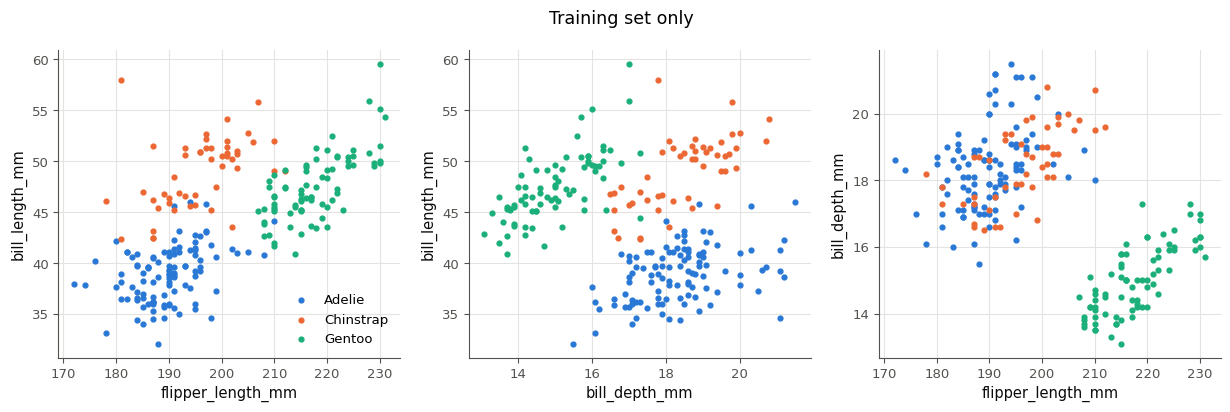

In [56]:
pairs = [("flipper_length_mm", "bill_length_mm"), ("bill_depth_mm", "bill_length_mm"), ("flipper_length_mm", "bill_depth_mm")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x_name, y_name) in zip(axes, pairs):
    for species in ["Adelie", "Chinstrap", "Gentoo"]:
        part = train[train["species"] == species]
        ax.scatter(part[x_name], part[y_name], s=12, label=species)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
axes[0].legend()
fig.suptitle("Training set only")
plt.show()

In [57]:
def my_rule(bill_length, bill_depth, flipper_length, body_mass):
    """Your own rules (at most 4 conditions): returns "Adelie", "Chinstrap" or "Gentoo"."""
    if flipper_length > 206 and bill_depth < 17.5:
        return "Gentoo"          # long flippers and a thin bill
    if bill_length > 44:
        return "Chinstrap"       # among the others, the long bills
    return "Adelie"


my_train_acc = accuracy(y_train, predict_with(my_rule, X_train))
my_test_acc = accuracy(y_test, predict_with(my_rule, X_test))
print(f"these rules: {my_train_acc:.1%} on the training set, {my_test_acc:.1%} on the test set")
print(pd.crosstab(y_test, predict_with(my_rule, X_test), rownames=["true"], colnames=["predicted"]))

these rules: 96.1% on the training set, 97.0% on the test set
predicted  Adelie  Chinstrap  Gentoo
true                                
Adelie         39          1       0
Chinstrap       1         18       0
Gentoo          0          1      40


💡 Une solution parmi d'autres : les Gentoo ont une longue nageoire **et** un bec fin ; parmi les autres, un bec long signe le Chinstrap. Trois règles lues sur les graphiques d'entraînement dépassent les 95 % sur le test. Tu as fait le travail d'un expert… que l'arbre de 1.18 a fait seul, en une seconde. Sur 784 pixels (MNIST), personne ne saurait écrire ces règles à la main : c'est là que le machine learning devient indispensable.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu décrire un dataset (échantillons, features, label) et dire à quelle famille appartient une tâche (classification, régression, clustering, renforcement, génération) ?
2. Sais-tu écrire une boucle d'entraînement minimale et expliquer ce que fait le learning rate ?
3. Sais-tu repérer une évaluation faussée (mémorisation, fuite du label, test vu à l'entraînement) ?

**Pour aller plus loin** : le *Machine Learning Crash Course* de Google et les vidéos de 3Blue1Brown sur les réseaux de neurones, cités dans la fiche. La suite : le ch. 2 (hasard et statistiques) donne les outils pour décrire les données et leurs fluctuations ; tu retrouveras le jeu de test au ch. 8, la régression au ch. 9, les neurones au ch. 10, le bandit au ch. 11, les arbres au ch. 13.